# Flood Calibration Workflow for Operators

**Purpose:** This notebook helps you set up a flood early warning system by analyzing historical river discharge data to find the best thresholds for calling "FLOOD" alerts.

**Who should use this:** Operations personnel with basic GIS knowledge (no advanced statistics required)

**Time required:** 2-3 hours for a typical basin

## ⚡ Quick Start (3 Easy Steps)

### Step 1: Configure (Section 2)
Edit 4 simple fields at the top:
- Where is your flood area? (city/town OR river basin)
- What years of historical data? (leave as "ALL" for best results)
- Give your analysis a name
- Who are you? (your name)

### Step 2: Run Workflow (Sections 3-5)
- Press "Run All" or go through each section
- **STOP at Section 6** to review the maps of your gauge locations
- Make sure the red dots look right on the maps

### Step 3: Calibrate & Document (Sections 7-10)
- The system automatically finds flood thresholds
- Review the recommendations (green checkmarks = good)
- Write down any special notes or decisions
- Everything is saved automatically

**All computations are automated. No equations to solve, no parameters to tune.**

---


## 1. Initialize Environment

This section sets up the notebook environment:
- Imports required libraries (philflood, spatial, statistics)
- Finds repository root and adds source code to path
- Initializes progress logger

**Action:** Run this cell first. If errors occur, check that repository paths are correct.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import psutil
from pathlib import Path

# --- Suppress ALL library logging (use ProgressLogger only) ---
logging.basicConfig(level=logging.CRITICAL)  # Only show CRITICAL errors
logging.getLogger('philflood').setLevel(logging.CRITICAL)
logging.getLogger('pyextremes').setLevel(logging.CRITICAL)
logging.getLogger('xarray').setLevel(logging.CRITICAL)
logging.getLogger('cfgrib').setLevel(logging.CRITICAL)
logging.getLogger('matplotlib').setLevel(logging.CRITICAL)
logging.getLogger('numexpr').setLevel(logging.CRITICAL)
logging.getLogger('PIL').setLevel(logging.CRITICAL)

# Suppress warnings
warnings.filterwarnings('ignore')

# Optional interactivity
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
    print('HAS_WIDGETS:', HAS_WIDGETS)
except Exception:
    HAS_WIDGETS = False
    print('HAS_WIDGETS:', HAS_WIDGETS)

# --- Find repo root and add src/ to sys.path ---
try:
    from philflood.utils.paths import find_repo_root, ensure_src_on_path
except Exception:
    # Fallback: assume this notebook lives under <repo>/notebooks/
    def find_repo_root(start=None):
        p = Path.cwd().resolve() if start is None else Path(start).resolve()
        for parent in (p, *p.parents):
            if (parent / 'src').exists():
                return parent
        raise RuntimeError('Could not find repo root; set REPO_ROOT manually')

    def ensure_src_on_path(repo_root):
        repo_root = Path(repo_root).resolve()
        src = repo_root / 'src'
        if str(src) not in sys.path:
            sys.path.insert(0, str(src))
        return src

REPO_ROOT = find_repo_root()
SRC_PATH = ensure_src_on_path(REPO_ROOT)
print('REPO_ROOT:', REPO_ROOT)
print('SRC_PATH :', SRC_PATH)

# Now imports from src/
from philflood.domain.config import load_basin_config
from philflood.geo.hydrobasins import read_vector, select_context_polygon, select_l12_by_geometry, get_id_field
from philflood.adapters.glofas_grib_v4 import (
    discover_grib_year_files,
    open_grib_dataset,
    nearest_grid_cell,
    load_or_build_gauge_timeseries,
)
from philflood.qc.timeseries import qc_daily_series, qc_summary_dict
from philflood.calibration.evt_pot import pot_extract, fit_gpd_to_pot
from philflood.models.ev.threshold_selection import auto_select_threshold_pot
from philflood.ops.logging_config import ProgressLogger

print('Core imports OK')

# Initialize progress logger for this session
log = ProgressLogger("EVT/POT Calibration Workflow")
log.step("Notebook initialized successfully")

HAS_WIDGETS: True
REPO_ROOT: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL
SRC_PATH : C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\src
Core imports OK
• Notebook initialized successfully


## 2. Define Your Analysis Area & Settings

**What this step does:**
- Choose whether to analyze a municipality area or a basin context
- Point to your GloFAS discharge data folder
- Select analysis time period

**User inputs:** Edit the cells below to specify:
1. Analysis mode (municipality or basin)
2. File paths (GloFAS data, geographic boundaries)
3. Year range for historical calibration

The notebook will validate your inputs and show any missing files.

In [2]:
# ==============================================================================
# SECTION 2A: SIMPLE USER INPUTS (Edit these fields)
# ==============================================================================
# This is all you need to change for most runs. See "Advanced Settings" below 
# for technical parameters.

log.section("SECTION 2: User Inputs")
log.step("Configuring your flood analysis...")

# --- OPTION 1: Where is your analysis area? ---
# Choose ONE of the following:
#   - Set ANALYZE_BY_MUNICIPALITY = True for city/town level analysis
#   - Set ANALYZE_BY_MUNICIPALITY = False for river basin analysis
ANALYZE_BY_MUNICIPALITY = False  # Change to True if analyzing a specific municipality

if ANALYZE_BY_MUNICIPALITY:
    # If analyzing municipality: provide the municipality IDs (one per line)
    municipality_ids = [
        # Example: "30758251B93060635103686",  # Gattaran, Cagayan
        # Add your municipality IDs here
    ]
else:
    # If analyzing basin: point to your basin configuration file
    basin_config_file = r"ops\configs\basins\Cagayan_01.yaml"

# --- OPTION 2: What years do you want to analyze? ---
# Set to None to use ALL available years (recommended)
# Or specify a list: [2020, 2021, 2022] to test specific years
years_to_analyze = None  # ALL years (recommended for initial calibration)

# --- OPTION 3: Give this run a name ---
# Used to organize output files. Example: "Jan2026_calib" or "Cagayan_pilot"
run_name = "2026-01-19_calib-test"

analyst_name = "David"  # Your name (recorded in decision log)

# ==============================================================================
# SECTION 2B: ADVANCED SETTINGS (Usually don't change these)
# ==============================================================================
log.step("Loading advanced settings...")

# --- Data paths (auto-configured from project structure) ---
# These paths are relative to your project root - normally no need to change
adm3_geojson = REPO_ROOT / "data/raw/vectors/admin/phl_cod_ab/phl_adm3.geojson"
hybas_l12_shp = REPO_ROOT / "data/raw/vectors/hydrobasins/australasia/hybas_au_lev01-12_v1c/hybas_au_lev12_v1c.shp"
hybas_pour_l12_shp = REPO_ROOT / "data/raw/vectors/hydrobasins/australasia/hybas_pour_lev01-12_v1_shp/hybas_pour_lev12_v1.shp"
glofas_grib_root = REPO_ROOT / "data/raw/glofas/historical/version_4_0/consolidated/discharge/grib2/area_35_63_4_131"

# --- Technical parameters ---
USE_CELL_EXTRACTION = True  # True = use all GloFAS grid cells, False = use pour point only
discharge_var = None  # Leave as None to auto-detect from GRIB files
run_tag = "2026-01-19_calib-test"

# --- Threshold selection parameters (POT analysis) ---
run_length_days = 5  # Minimum event separation (days)
candidate_quantiles = [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]  # Percentiles to test

# --- Processing output root ---
processed_root = REPO_ROOT / "data" / "processed"

# === Settings from simple inputs ===
# Convert simple inputs to internal variables
USE_MUNI_AOI = ANALYZE_BY_MUNICIPALITY
SELECTED_YEARS = years_to_analyze
adm3_ids = municipality_ids if ANALYZE_BY_MUNICIPALITY else []
basin_cfg_relpath = basin_config_file if not ANALYZE_BY_MUNICIPALITY else None
context_select_mode = "within"

log.table("Configuration Summary", {
    "Analysis mode": "Municipality AOI" if USE_MUNI_AOI else "Context basin",
    "Years": f"ALL ({run_length_days}+ day gaps)" if SELECTED_YEARS is None else f"{len(SELECTED_YEARS)} specific years",
    "Run name": run_name,
    "Output folder": str(processed_root),
    "Analyst": analyst_name,
})
log.success("Configuration ready")



  SECTION 2: User Inputs
• Configuring your flood analysis...
• Loading advanced settings...

Configuration Summary:
  Analysis mode........................... Context basin
  Years................................... ALL (5+ day gaps)
  Run name................................ 2026-01-19_calib-test
  Output folder........................... C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed
  Analyst................................. David
✓ Configuration ready


In [3]:
# ==============================================================================
# INPUT VALIDATION: CHECK THAT ALL FILES & SETTINGS ARE CORRECT
# ==============================================================================
# If you see RED ❌ messages below, fix the settings above and re-run this cell

log.section("INPUT VALIDATION")
validation_errors = []
validation_warnings = []

# Check 1: Required data files exist
log.step("Checking required data files...")
required_files = {
    "Municipality boundaries (ADM3)": adm3_geojson,
    "River basins (Level 12)": hybas_l12_shp,
    "Basin pour points": hybas_pour_l12_shp,
    "GloFAS weather data": glofas_grib_root,
}

for name, path in required_files.items():
    if not path.exists():
        # Only show full path when there's an error (operators need to fix it)
        validation_errors.append(f"{name}: NOT FOUND at {path}")
        log.error(f"❌ {name} - File missing")
        print(f"   Expected location: {path}")
    else:
        # Just show friendly name when OK
        log.success(f"✓ {name}")

# Check 2: Municipality IDs provided (if in municipality mode)
log.step("Checking analysis area settings...")
if USE_MUNI_AOI:
    if not adm3_ids or len(adm3_ids) == 0:
        validation_errors.append("Municipality mode selected but no IDs provided")
        log.error("❌ Municipality mode: no IDs provided")
    else:
        log.success(f"✓ {len(adm3_ids)} municipality IDs provided")
else:
    # Resolve basin config file path relative to REPO_ROOT
    basin_cfg_path = REPO_ROOT / basin_config_file
    if not basin_config_file or not basin_cfg_path.exists():
        validation_errors.append(f"Basin config file not found: {basin_config_file}")
        log.error(f"❌ Basin config file not found")
        print(f"   Expected: {basin_cfg_path}")
    else:
        log.success(f"✓ Basin config: {Path(basin_config_file).name}")

# Check 3: Output directory is writable
log.step("Checking output directory...")
try:
    output_dir = processed_root / "calibration"
    output_dir.mkdir(parents=True, exist_ok=True)
    test_file = output_dir / ".test_write"
    test_file.write_text("test")
    test_file.unlink()
    # Show relative path from repo root for readability
    rel_path = output_dir.relative_to(REPO_ROOT)
    log.success(f"✓ Output directory: {rel_path}")
except Exception as e:
    validation_errors.append(f"Cannot write to output directory: {e}")
    log.error(f"❌ Output directory not writable")
    print(f"   Location: {output_dir}")
    print(f"   Error: {e}")

# Check 4: Run name is reasonable
if not run_name or len(run_name) < 3:
    validation_warnings.append("Run name is too short (recommend 10+ characters for clarity)")
    log.warn(f"⚠️ Run name is very short: '{run_name}'")
else:
    log.success(f"✓ Run name: '{run_name}'")

# Check 5: Analyst name provided
if not analyst_name or len(analyst_name) < 2:
    validation_warnings.append("Analyst name missing or too short")
    log.warn("⚠️ Analyst name missing")
else:
    log.success(f"✓ Analyst: {analyst_name}")

# Summary: Report results
log.section("VALIDATION SUMMARY")
if validation_errors:
    log.error(f"❌ {len(validation_errors)} CRITICAL ERRORS found:")
    for i, err in enumerate(validation_errors, 1):
        print(f"   {i}. {err}")
    print("\n⚠️  STOP: Fix the errors above and re-run this cell before continuing!")
    raise ValueError(f"Validation failed: {validation_errors[0]}")
elif validation_warnings:
    log.warn(f"⚠️ {len(validation_warnings)} warnings (non-critical):")
    for i, warn in enumerate(validation_warnings, 1):
        print(f"   {i}. {warn}")
    log.success("✓ You can proceed (warnings are optional)")
else:
    log.success("✓✓✓ ALL CHECKS PASSED! Ready to continue to next section ✓✓✓")



  INPUT VALIDATION
• Checking required data files...
✓ ✓ Municipality boundaries (ADM3)
✓ ✓ River basins (Level 12)
✓ ✓ Basin pour points
✓ ✓ GloFAS weather data
• Checking analysis area settings...
✓ ✓ Basin config: Cagayan_01.yaml
• Checking output directory...
✓ ✓ Output directory: data\processed\calibration
✓ ✓ Run name: '2026-01-19_calib-test'
✓ ✓ Analyst: David

  VALIDATION SUMMARY
✓ ✓✓✓ ALL CHECKS PASSED! Ready to continue to next section ✓✓✓


## 3. Load Geographic Boundaries

**What this step does:**
- Loads administrative boundaries (municipalities, river basins)
- Identifies which areas you want to analyze
- Prepares spatial data for gauge location selection

**No user inputs needed** - uses the settings from Section 2

In [4]:
import geopandas as gpd
from shapely.geometry import box

log.section("SECTION 3: Load Geographic Boundaries")

# === Helper Function: Spatial-Filtered Vector Loading ===
def read_vector_with_spatial_filter(path, filter_geometry, enforce_epsg4326=True):
    """Load vector with spatial filter to select complete polygons.
    
    Uses spatial relationship (intersects) to select complete polygons 
    that overlap or touch the filter geometry. This avoids topology 
    errors from bbox clipping by keeping polygon boundaries intact.
    
    Args:
        path: Path to shapefile/geojson
        filter_geometry: Shapely geometry to filter by (e.g., buffered polygon)
        enforce_epsg4326: Convert to EPSG:4326 if needed
    
    Returns:
        GeoDataFrame with complete polygons intersecting filter_geometry
    """
    try:
        # First try native fiona spatial filter (fastest)
        import fiona
        bounds = filter_geometry.bounds  # (minx, miny, maxx, maxy)
        with fiona.open(path, bbox=bounds) as src:
            gdf = gpd.GeoDataFrame.from_features(src, crs=src.crs)
        
        if gdf.empty:
            log.warn(f"No features in bbox, falling back to full load + spatial filter")
            gdf = gpd.read_file(path)
        else:
            log.step(f"  Loaded {len(gdf)} features via fiona bbox filter")
    except Exception as e:
        log.warn(f"  Fiona filter failed: {e}, using standard load")
        gdf = gpd.read_file(path)
    
    # Ensure CRS
    if enforce_epsg4326 and gdf.crs != "EPSG:4326":
        gdf = gdf.to_crs("EPSG:4326")
    
    # Apply spatial filter: keep complete polygons that intersect the geometry
    # Using .intersects() ensures we get the full polygon, not clipped versions
    gdf_filtered = gdf[gdf.geometry.intersects(filter_geometry)].copy()
    
    return gdf_filtered

# === Step 1: Always load small ADM3 first ===
log.step("Loading ADM3 municipalities...")
adm3_gdf = read_vector(adm3_geojson)
log.step(f"  Loaded {len(adm3_gdf)} municipalities")

adm3_id_field = "adm3_id" if "adm3_id" in adm3_gdf.columns else None
if adm3_id_field is None:
    log.error("ADM3 must have 'adm3_id' column")
    raise KeyError("Missing adm3_id")

# === Step 2: Compute spatial filter geometry based on mode ===
basin_cfg = None
target_level = None

if USE_MUNI_AOI:
    log.step(f"Municipality mode: Computing bbox from {len(adm3_ids)} municipalities...")
    
    # Get bbox from selected municipalities
    muni_subset = adm3_gdf[adm3_gdf[adm3_id_field].isin(adm3_ids)]
    bounds = muni_subset.total_bounds  # [minx, miny, maxx, maxy]
    
    # Create buffered geometry to capture upstream basins
    buffer_deg = 2.0  # ~220 km buffer at equator
    filter_geom = box(
        bounds[0] - buffer_deg,  # minx
        bounds[1] - buffer_deg,  # miny
        bounds[2] + buffer_deg,  # maxx
        bounds[3] + buffer_deg   # maxy
    )
    
    log.step(f"  Filter bbox: lon [{filter_geom.bounds[0]:.2f}, {filter_geom.bounds[2]:.2f}], "
             f"lat [{filter_geom.bounds[1]:.2f}, {filter_geom.bounds[3]:.2f}]")
else:
    log.step("Context basin mode: Computing bbox from context basin...")
    basin_cfg = load_basin_config(basin_cfg_path)
    
    # Load ONLY the context basin level (small - e.g., L7)
    target_level = int(basin_cfg.hydrobasins_level)
    
    if target_level == 12:
        context_gdf_temp = read_vector(hybas_l12_shp)
        log.step(f"  Loaded L12 for context basin selection")
    else:
        level_str = f"{target_level:02d}"
        hybas_parent = hybas_l12_shp.parent
        hybas_context = hybas_parent / f"hybas_au_lev{level_str}_v1c.shp"
        
        if not hybas_context.exists():
            log.error(f"HydroBASINS level {target_level} not found: {hybas_context}")
            raise FileNotFoundError(f"HydroBASINS level {target_level} shapefile not found at: {hybas_context}")
        
        context_gdf_temp = read_vector(hybas_context)
        log.step(f"  Loaded L{target_level} for context basin selection: {len(context_gdf_temp)} polygons")
    
    # Select the specific basin
    context_sel = select_context_polygon(context_gdf_temp, basin_cfg.hydrobasins_id)
    context_geom = context_sel.geometry.values[0]
    bounds = context_sel.total_bounds
    
    # Create buffered geometry (smaller buffer for basin mode)
    buffer_deg = 1.0  # ~110 km buffer at equator
    filter_geom = box(
        bounds[0] - buffer_deg,
        bounds[1] - buffer_deg,
        bounds[2] + buffer_deg,
        bounds[3] + buffer_deg
    )
    
    log.step(f"  Filter bbox: lon [{filter_geom.bounds[0]:.2f}, {filter_geom.bounds[2]:.2f}], "
             f"lat [{filter_geom.bounds[1]:.2f}, {filter_geom.bounds[3]:.2f}]")

# === Step 3: Load L12 and pour points with spatial filter ===
# This uses .intersects() to select COMPLETE polygons, avoiding topology errors
log.step("Loading L12 basins with spatial filter (selecting complete polygons)...")
l12_gdf = read_vector_with_spatial_filter(hybas_l12_shp, filter_geom)
log.step(f"  ✓ Filtered to {len(l12_gdf)} L12 basins (from full Australasia dataset)")

log.step("Loading pour points with spatial filter...")
pour_gdf = read_vector_with_spatial_filter(hybas_pour_l12_shp, filter_geom)
log.step(f"  ✓ Filtered to {len(pour_gdf)} pour points")

# === Step 4: Setup context for later use ===
context_gdf = None
context_geom = None

if not USE_MUNI_AOI:
    # Already loaded context basin above (basin_cfg and target_level available from Step 2)
    context_gdf = context_gdf_temp
    basin_name = basin_cfg.basin_id if basin_cfg else "BASIN_MODE"
    log.success(f"Context basin L{target_level}: {basin_name}")

# Get ID field names
l12_id_field = get_id_field(l12_gdf)
pour_id_field = get_id_field(pour_gdf)

log.table("Vector Data Loaded", {
    "ADM3 (municipalities)": len(adm3_gdf),
    "L12 (filtered basins)": len(l12_gdf),
    "Pour points (filtered)": len(pour_gdf),
    "Filter strategy": "Municipality AOI" if USE_MUNI_AOI else f"Context basin L{target_level}",
    "Spatial selection": "Intersects (complete polygons preserved)",
})

log.success("Section 3 complete: Spatial-filtered vectors loaded")


  SECTION 3: Load Geographic Boundaries
• Loading ADM3 municipalities...
•   Loaded 1647 municipalities
• Context basin mode: Computing bbox from context basin...
•   Loaded L7 for context basin selection: 4670 polygons
•   Filter bbox: lon [120.53, 123.12], lat [16.20, 19.09]
• Loading L12 basins with spatial filter (selecting complete polygons)...
•   Loaded 83929 features via fiona bbox filter
•   ✓ Filtered to 381 L12 basins (from full Australasia dataset)
• Loading pour points with spatial filter...
•   Loaded 5271492 features via fiona bbox filter
•   ✓ Filtered to 2819 pour points
✓ Context basin L7: Cagayan_01

Vector Data Loaded:
  ADM3 (municipalities)................... 1647
  L12 (filtered basins)................... 381
  Pour points (filtered).................. 2819
  Filter strategy......................... Context basin L7
  Spatial selection....................... Intersects (complete polygons preserved)
✓ Section 3 complete: Spatial-filtered vectors loaded


## 4. Find Virtual Gauge Locations

**What this step does:**
- Selects which river sub-basins (L12 hydro-regions) to analyze
- Finds representative gauge locations (nearest GloFAS grid cell for each sub-basin)

**Key concept:** One virtual gauge per sub-basin
- Multiple sub-basins may share the same GloFAS grid cell (expected)
- We calibrate separately for each UNIQUE gauge location

**Two analysis modes:**

- **Mode A - Municipality Analysis:** Analyzes discharge in smaller river sub-basins that overlap your selected municipality (good for local risk assessment)
- **Mode B - Full Basin Analysis:** Analyzes the entire configured river basin, e.g., Cagayan or Agusan (good for regional risk assessment)

**No user inputs needed** - uses the settings from Section 2

In [5]:
log.section("SECTION 4: Select L12 Impact Units")

selected_l12 = None
muni_aoi_records = []

if USE_MUNI_AOI:
    if not adm3_ids:
        log.error("USE_MUNI_AOI=True requires adm3_ids to be provided")
        raise ValueError("USE_MUNI_AOI=True requires adm3_ids to be provided")
    
    log.step(f"Processing {len(adm3_ids)} municipality/municipalities...")
    log.step("Selecting L12 basins that intersect each municipality polygon...")

    for mid in adm3_ids:
        muni = adm3_gdf[adm3_gdf[adm3_id_field] == mid]
        if len(muni) != 1:
            raise ValueError(f"Expected exactly 1 municipality for adm3_id={mid}, found {len(muni)}")
        muni_geom = muni.geometry.values[0]

        # Direct L12 selection: all L12s that spatially intersect the municipality polygon
        sel = select_l12_by_geometry(l12_gdf, muni_geom, mode="intersects")

        muni_aoi_records.append({
            "adm3_id": mid,
            "centroid_lon": None,  # No longer computed; using direct intersection
            "centroid_lat": None,  # No longer computed; using direct intersection
            "total_population": None,  # Population weighting removed
            "valid_pixel_count": None,  # Population weighting removed
            "n_l12_selected": int(len(sel)),
            "l12_ids": sel[l12_id_field].astype(int).tolist(),
        })
        log.step(f"  {mid}: {len(sel)} L12 basins selected (direct municipality intersection)")

    # Union selection across municipalities
    all_ids = sorted({i for r in muni_aoi_records for i in r["l12_ids"]})
    selected_l12 = l12_gdf[l12_gdf[l12_id_field].astype(int).isin(all_ids)].copy()

else:
    # Context basin mode
    log.step("Context basin mode: Selecting L12 by geometry...")
    context_sel = select_context_polygon(context_gdf, basin_cfg.hydrobasins_id)
    context_geom = context_sel.geometry.values[0]
    selected_l12 = select_l12_by_geometry(l12_gdf, context_geom, mode=context_select_mode)
    log.step(f"Selected {len(selected_l12)} L12 basins")

log.success(f"Section 4 complete: {len(selected_l12)} L12 basins selected")


  SECTION 4: Select L12 Impact Units
• Context basin mode: Selecting L12 by geometry...
• Selected 36 L12 basins
✓ Section 4 complete: 36 L12 basins selected


## 5. Set Up Virtual Gauges (Gauge-Grid Mapping)

**What this step does:**
- For each selected river sub-basin: finds the representative discharge "point"
- Maps that point to the nearest GloFAS grid cell (our "virtual gauge")
- Checks for collisions (multiple sub-basins → same GloFAS cell) - EXPECTED and HANDLED

**Key concept:** Multiple river sub-basins may point to the same GloFAS grid cell. This is normal.
We calibrate separately for each UNIQUE gauge location.

In [6]:
log.section("SECTION 5: Build Virtual Gauges")

# Join selected L12 to pour points
log.step("Building L12→GloFAS cell mapping...")

# Discover GRIB inventory for grid access
log.step("Discovering GloFAS GRIB inventory...")
inventory = discover_grib_year_files(glofas_grib_root, selected_years=SELECTED_YEARS)
log.step(f"Discovered {len(inventory)} yearly GRIBs: {inventory[0].year}..{inventory[-1].year}")

if USE_CELL_EXTRACTION:
    # ========== CELL-LEVEL EXTRACTION ==========
    log.step("MODE: Cell-level extraction (all cells INTERSECTING L12 polygons)")
    log.step("  Strategy: Includes cells whose boundaries touch/overlap L12 polygons")
    log.step("  (not just cells with centroids inside polygon)")
    
    # Open one GRIB to access grid structure
    sample_grib = inventory[0].grib_path
    index_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "_cfgrib_index"
    ds = open_grib_dataset(sample_grib, index_dir=index_dir)
    
    from philflood.adapters.glofas_grib_v4 import cells_within_polygon
    
    # For each L12 polygon, find all intersecting grid cells (boundary-based)
    cell_records = []
    for l12_id, l12_geom in zip(selected_l12[l12_id_field], selected_l12.geometry):
        cells_df = cells_within_polygon(ds, l12_geom)
        if cells_df.empty:
            log.warn(f"L12 {l12_id}: no GloFAS cells intersect polygon")
            continue
        cells_df['l12_id'] = l12_id
        cell_records.append(cells_df)
    
    try:
        ds.close()
    except Exception:
        pass
    
    if not cell_records:
        log.error("No grid cells found in any L12 polygons!")
        raise RuntimeError("No grid cells found in any L12 polygons")
    
    # Concatenate all cells
    points_df = pd.concat(cell_records, ignore_index=True)
    points_df = points_df.rename(columns={'cell_lat': 'lat', 'cell_lon': 'lon'})
    
    # Create gauge IDs by unique cell coordinates
    points_df['virtual_gauge_id'] = points_df.apply(
        lambda r: f"CELL__lat_{r['lat']:.4f}__lon_{r['lon']:.4f}", axis=1
    )
    
    # Track how many L12 basins share each cell
    cell_to_l12 = points_df.groupby('virtual_gauge_id')['l12_id'].nunique().rename('l12_count')
    points_df = points_df.merge(cell_to_l12, on='virtual_gauge_id', how='left')
    
    unique_gauges = points_df['virtual_gauge_id'].nunique()
    total_cells = len(points_df)
    shared_cells = (points_df['l12_count'] > 1).sum()
    
    log.table("Cell-Level Extraction Summary", {
        "Total L12 basins": len(selected_l12),
        "Unique grid cells": unique_gauges,
        "Cell-basin associations": total_cells,
        "Cells shared by multiple L12s": shared_cells,
        "Max L12s per cell": int(points_df['l12_count'].max()),
    })

else:
    # ========== POUR POINT EXTRACTION (DEFAULT) ==========
    log.step("MODE: Pour point extraction (single outlet per L12)")
    
    pour_sel = pour_gdf[[pour_id_field, "geometry"]].copy()
    pour_sel[pour_id_field] = pour_sel[pour_id_field].astype(int)

    sel = selected_l12[[l12_id_field, "geometry"]].copy()
    sel[l12_id_field] = sel[l12_id_field].astype(int)

    # Merge by HYBAS_ID
    sel = sel.merge(pour_sel, left_on=l12_id_field, right_on=pour_id_field, how="left", suffixes=("_l12", "_pour"))
    if sel["geometry_pour"].isna().any():
        missing = sel[sel["geometry_pour"].isna()][l12_id_field].tolist()
        log.error(f"Missing pour points for L12 IDs: {missing[:10]}")
        raise RuntimeError(f"Missing pour points for some L12 IDs: {missing[:10]} (showing up to 10)")

    # Build a points dataframe
    points_df = pd.DataFrame({
        "l12_id": sel[l12_id_field].astype(int).values,
        "pour_lon": sel["geometry_pour"].x.astype(float).values,
        "pour_lat": sel["geometry_pour"].y.astype(float).values,
    })

    log.step(f"Prepared {len(points_df)} L12 pour points")

    # Open one GRIB (first available year) to get grid and assign nearest cells
    log.step("Discovering GloFAS grid and mapping to nearest cells...")

    sample_grib = inventory[0].grib_path
    index_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "_cfgrib_index"

    ds = open_grib_dataset(sample_grib, index_dir=index_dir)

    cell_lats = []
    cell_lons = []
    for lon, lat in zip(points_df["pour_lon"], points_df["pour_lat"]):
        lat0, lon0 = nearest_grid_cell(ds, lat=float(lat), lon=float(lon))
        cell_lats.append(lat0)
        cell_lons.append(lon0)

    try:
        ds.close()
    except Exception:
        pass

    points_df["lat"] = cell_lats
    points_df["lon"] = cell_lons

    # Define virtual gauge id by unique cell coordinates (stable string)
    points_df["virtual_gauge_id"] = points_df.apply(lambda r: f"VG__lat_{r.lat:.4f}__lon_{r.lon:.4f}", axis=1)

    # Collision grouping
    collision_sizes = points_df.groupby("virtual_gauge_id")["l12_id"].nunique().rename("collision_group_size")
    points_df = points_df.merge(collision_sizes, on="virtual_gauge_id", how="left")

    unique_gauges = points_df["virtual_gauge_id"].nunique()
    max_collision = int(points_df["collision_group_size"].max())

    log.table("Pour Point Extraction Summary", {
        "Unique virtual gauges": unique_gauges,
        "Max collision group size": max_collision,
        "Total L12 basins": len(points_df),
    })

# Extract unique gauge points for extraction
vg_points = points_df.drop_duplicates("virtual_gauge_id")[["virtual_gauge_id", "lat", "lon"]].copy()

log.success(f"Section 5 complete: {len(vg_points)} unique virtual gauges created (extraction method: {'CELL' if USE_CELL_EXTRACTION else 'POUR POINT'})")


  SECTION 5: Build Virtual Gauges
• Building L12→GloFAS cell mapping...
• Discovering GloFAS GRIB inventory...
• Discovered 47 yearly GRIBs: 1979..2025
• MODE: Cell-level extraction (all cells INTERSECTING L12 polygons)
•   Strategy: Includes cells whose boundaries touch/overlap L12 polygons
•   (not just cells with centroids inside polygon)

Cell-Level Extraction Summary:
  Total L12 basins........................ 36
  Unique grid cells....................... 180
  Cell-basin associations................. 384
  Cells shared by multiple L12s........... 323
  Max L12s per cell....................... 7
✓ Section 5 complete: 180 unique virtual gauges created (extraction method: CELL)


## 6. Verify Maps & Review Virtual Gauge Assignments

**What you'll see:**
- Maps showing your selected region (municipality or basin)
- Rivers sub-basins (L12 polygons) overlaid on satellite imagery
- Virtual gauge locations (red dots = representative discharge points)
- GloFAS grid cells for reference

**Review the maps to ensure:**
- Gauge locations are in reasonable places (not water, not mountains)
- Gauge distribution covers the entire analysis area

In [7]:
# Helper function to add GloFAS grid overlay to maps
def _cell_edges(x):
    """Compute cell-edge coordinates from cell-center coordinates."""
    mid = (x[:-1] + x[1:]) / 2.0
    first = x[0] - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.concatenate([[first], mid, [last]])

def add_glofas_grid_overlay(
    ax,
    ds,
    bbox_lonlat,
    pad_deg: float = 0.25,
    max_lines: int = 250,
    alpha: float = 0.40,
    linewidth: float = 0.60,
    zorder: int = 0,
):
    """
    Add subtle GloFAS grid-cell boundaries to an existing lon/lat plot.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes on which to draw the grid lines.
    ds : xarray.Dataset
        An opened GloFAS GRIB dataset (to extract lat/lon coordinates).
    bbox_lonlat : tuple
        (minx, miny, maxx, maxy) bounding box in lon/lat.
    pad_deg : float
        Padding in degrees around the bounding box.
    max_lines : int
        Safety limit on number of grid lines to draw.
    alpha : float
        Transparency of the grid lines (0=invisible, 1=opaque).
    linewidth : float
        Width of the grid lines.
    zorder : int
        Drawing layer (0 = behind most other features).
    """
    from philflood.adapters.glofas_grib_v4 import infer_lat_lon_names
    
    lat_name, lon_name = infer_lat_lon_names(ds)
    lats = ds[lat_name].values
    lons = ds[lon_name].values

    minx, miny, maxx, maxy = bbox_lonlat
    minx -= pad_deg
    maxx += pad_deg
    miny -= pad_deg
    maxy += pad_deg

    # Filter to visible range
    lats_vis = lats[(lats >= miny) & (lats <= maxy)]
    lons_vis = lons[(lons >= minx) & (lons <= maxx)]

    if len(lats_vis) == 0 or len(lons_vis) == 0:
        return  # Nothing to draw

    # Compute cell edges
    lat_edges = _cell_edges(lats_vis)
    lon_edges = _cell_edges(lons_vis)

    # Safety check
    total_lines = len(lat_edges) + len(lon_edges)
    if total_lines > max_lines:
        return  # Skip if too many lines

    # Draw horizontal lines (constant latitude)
    for lat_edge in lat_edges:
        ax.plot([minx, maxx], [lat_edge, lat_edge], 
                color="gray", alpha=alpha, linewidth=linewidth, zorder=zorder)

    # Draw vertical lines (constant longitude)
    for lon_edge in lon_edges:
        ax.plot([lon_edge, lon_edge], [miny, maxy], 
                color="gray", alpha=alpha, linewidth=linewidth, zorder=zorder)

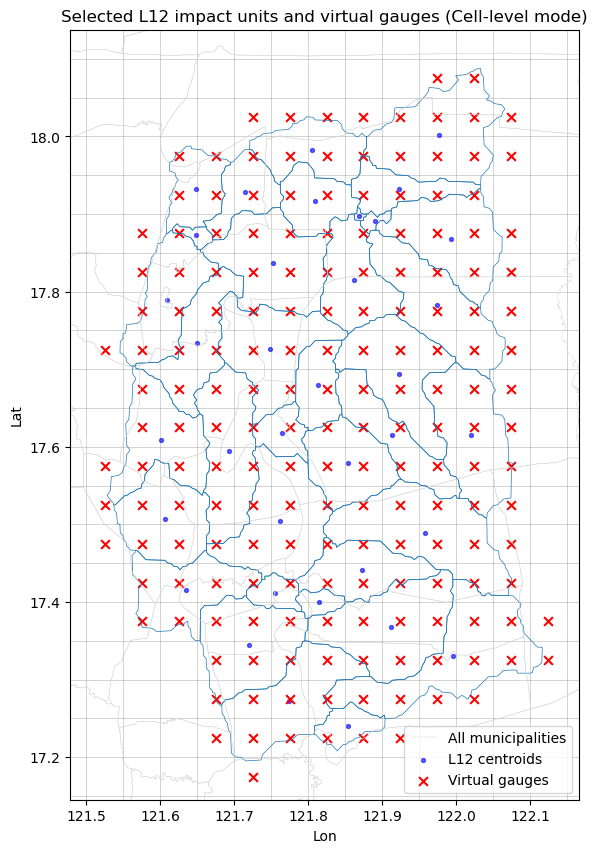

In [8]:
import geopandas as gpd
from shapely.geometry import Point

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Open one sample GRIB to get the GloFAS grid
inventory = discover_grib_year_files(glofas_grib_root)
sample_grib = inventory[0].grib_path
ds = open_grib_dataset(sample_grib, index_dir=index_dir)

# Add subtle GloFAS grid behind everything (bbox from selected_l12)
bbox = tuple(selected_l12.geometry.total_bounds)  # Use selected_l12 bounds instead of adm3
add_glofas_grid_overlay(ax, ds, bbox_lonlat=bbox, pad_deg=0.15)

try:
    ds.close()
except Exception:
    pass

# Base: selected L12
selected_l12.boundary.plot(ax=ax, linewidth=0.5)
# ALL municipalities (light background)
adm3_gdf.boundary.plot(ax=ax, linewidth=0.3, color="lightgray", alpha=1, label="All municipalities")

# AOI (if any) - only in municipality mode
if USE_MUNI_AOI:
    # Get selected municipalities' geometries
    muni_subset = adm3_gdf[adm3_gdf[adm3_id_field].isin(adm3_ids)]
    muni_subset.boundary.plot(ax=ax, linewidth=2.0, color="red", label="Selected municipalities")

# Pour points or cell source points (depends on extraction mode)
if USE_CELL_EXTRACTION:
    # Cell-level: cells_within_polygon doesn't produce pour points, only cell coordinates
    # Show the L12 centroids instead for reference
    l12_centroids = selected_l12.copy()
    l12_centroids['geometry'] = l12_centroids.geometry.centroid
    l12_centroids.plot(ax=ax, markersize=8, color='blue', label='L12 centroids', alpha=0.6)
else:
    # Pour-point mode: show the pour points
    pp = gpd.GeoDataFrame(points_df, geometry=[Point(xy) for xy in zip(points_df.pour_lon, points_df.pour_lat)], crs="EPSG:4326")
    pp.plot(ax=ax, markersize=8, label='Pour points')

# Virtual gauges (unique cells)
vg_unique = points_df.drop_duplicates("virtual_gauge_id").copy()
vg = gpd.GeoDataFrame(vg_unique, geometry=[Point(xy) for xy in zip(vg_unique.lon, vg_unique.lat)], crs="EPSG:4326")
vg.plot(ax=ax, markersize=40, marker="x", color='red', label='Virtual gauges')

ax.set_title(f"Selected L12 impact units and virtual gauges ({'Cell-level' if USE_CELL_EXTRACTION else 'Pour-point'} mode)")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.legend()

# Zoom to selected_l12 bounds (centered, tight)
bounds = selected_l12.geometry.total_bounds
minx, miny, maxx, maxy = bounds
pad = 0.05  # degrees; small padding for tightness
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

plt.show()


## 6. Review Gauge Locations ⏸️

**⚠️ STOP HERE and review the maps above**

**Check that:**
- ✓ All gauge markers (red dots) are inside your analysis area
- ✓ Locations are realistic (not in ocean or mountains)
- ✓ They cover the areas you want to monitor

**If something looks wrong:**
1. Return to **Section 2** and verify your inputs
2. Check municipality IDs or basin config file
3. Re-run the validation cell
4. Re-run from Section 3 onward

**If maps look correct:**
Proceed to Section 7 to save these gauge locations.


## 7. Save Gauge Mapping Tables

This step creates reference tables that link:
- **Risk units (administrative areas) → Virtual gauge locations**
- **Virtual gauges → GloFAS grid cells**
- **Collision information** (where multiple gauges share same grid cell)

These tables are saved and used in later stages of forecasting.

In [9]:
log.section("SECTION 7: Write Mapping Tables")

out_root = processed_root / "calibration" / "evt_pot" / (basin_cfg.basin_id if basin_cfg else "MUNI_SELECTION") / run_tag
mapping_dir = out_root / "mapping"
aoi_dir = out_root / "aoi"
for d in [mapping_dir, aoi_dir]:
    d.mkdir(parents=True, exist_ok=True)

log.step("Writing mapping tables...")

# A) muni → AOI → L12
if USE_MUNI_AOI:
    muni_aoi_df = pd.DataFrame(muni_aoi_records)
    muni_aoi_df.to_parquet(mapping_dir / "muni_aoi_l12.parquet", index=False)
    log.step(f"Wrote {len(muni_aoi_df)} municipality AOI records")

    # Save selected municipality geometries (no buffer/AOI - direct intersection approach)
    import geopandas as gpd
    selected_munis = adm3_gdf[adm3_gdf[adm3_id_field].isin(adm3_ids)].copy()
    selected_munis.to_file(aoi_dir / "selected_municipalities.geojson", driver="GeoJSON")
    log.step(f"Wrote {len(selected_munis)} selected municipality geometries to {aoi_dir}")

# B) L12 → grid cell mapping (adaptive to both extraction modes)
if USE_CELL_EXTRACTION:
    # Cell-level mode: L12 → cells (many cells per L12 possible)
    l12_cells = points_df[["l12_id", "lat", "lon"]].copy()
    l12_cells.to_parquet(mapping_dir / "l12_cell_coordinates.parquet", index=False)
    log.step(f"Wrote {len(l12_cells)} L12↔cell mappings")
else:
    # Pour-point mode: L12 → single pour point → single cell
    l12_pour = points_df[["l12_id", "pour_lon", "pour_lat"]].copy()
    l12_pour.to_parquet(mapping_dir / "l12_pour_points.parquet", index=False)
    log.step(f"Wrote {len(l12_pour)} pour point coordinates")

# C) L12 → virtual gauge (unique cell ID)
l12_vg = points_df[["l12_id", "virtual_gauge_id", "lat", "lon"]].drop_duplicates("virtual_gauge_id").copy()
l12_vg.to_parquet(mapping_dir / "l12_virtual_gauge.parquet", index=False)
log.step(f"Wrote {len(l12_vg)} L12↔virtual gauge mappings")

# D) Virtual gauge collision groups (how many L12s share each cell)
if USE_CELL_EXTRACTION:
    # For cell-level, we already have l12_count in points_df
    vg_collision = points_df[["virtual_gauge_id", "l12_count"]].drop_duplicates("virtual_gauge_id").copy()
else:
    # For pour-point mode, also already computed in Section 5
    vg_collision = points_df[["virtual_gauge_id", "collision_group_size"]].drop_duplicates("virtual_gauge_id").copy()
    vg_collision = vg_collision.rename(columns={"collision_group_size": "l12_count"})

vg_collision.to_parquet(mapping_dir / "virtual_gauge_collision_sizes.parquet", index=False)
log.step(f"Wrote collision group sizes for {len(vg_collision)} virtual gauges")

log.success("Section 7 complete: Mapping tables written")



  SECTION 7: Write Mapping Tables
• Writing mapping tables...
• Wrote 384 L12↔cell mappings
• Wrote 180 L12↔virtual gauge mappings
• Wrote collision group sizes for 180 virtual gauges
✓ Section 7 complete: Mapping tables written


In [10]:
log.section("SECTION 7: Validate GRIB Files")

from pathlib import Path

bad = []
small = []
ok = 0

log.step("Checking GRIB file integrity...")

for item in inventory:
    p = Path(item.grib_path)
    if not p.exists():
        bad.append((item.year, "MISSING", str(p)))
        continue

    size = p.stat().st_size
    head = p.open("rb").read(4)

    if head != b"GRIB":
        bad.append((item.year, f"NOT_GRIB magic={head!r}", str(p)))
        continue

    if size < 5 * 1024 * 1024:  # <5MB is suspicious for "yearly consolidated discharge"
        small.append((item.year, f"{size/1024**2:.2f} MB", str(p)))
        continue

    ok += 1

log.table("GRIB Integrity Check", {
    "OK files": ok,
    "Missing files": len(bad),
    "Suspiciously small": len(small),
})

if bad:
    log.warn(f"BAD examples: {bad[:5]}")
if small:
    log.warn(f"SMALL examples: {small[:5]}")

log.success("GRIB file validation complete")


  SECTION 7: Validate GRIB Files
• Checking GRIB file integrity...

GRIB Integrity Check:
  OK files................................ 47
  Missing files........................... 0
  Suspiciously small...................... 0
✓ GRIB file validation complete


### ✅ CHECKPOINT: Gauge Setup Complete

**What you just did:**
- ✓ Mapped each river sub-basin to its representative gauge location
- ✓ Validated GRIB weather data files are intact
- ✓ Saved mapping tables for future use

**What's next:**
- **Section 8**: Extract historical discharge records (automated)
- **Section 9**: Calibrate flood thresholds (requires your review)

**Ready to continue?** Run the next section when you're ready

## 8. Extract Historical Discharge Data from Weather Archive

**What this step does:**
Reads river discharge data from the GloFAS weather archive (GRIB files) and creates daily time series for each of your virtual gauge locations.

**How it works:**
- Downloads available years automatically (or uses cached data if already downloaded)
- Skips data that has already been processed (unless you force reprocessing)
- Converts raw GRIB format into readable tables (parquet files) organized by gauge

**Output:** Daily discharge time series for each virtual gauge (ready for analysis)

In [11]:
# ============================================================================
# 8a) EXTRACTION METHOD CONFIGURATION
# ============================================================================
# Choose extraction method and configure memory optimization.
#
# ⭐ STREAMING EXTRACTION (RECOMMENDED) ⭐
# - Processes one year at a time, writes immediately to disk
# - Constant memory usage regardless of dataset size
# - Scales to country-level deployments (1000s of gauges)
# - Supports resumption if crashes occur
# - Works on cloud and local machines
#
# LEGACY EXTRACTION (Original method)
# - Loads all years into memory, then writes
# - Memory usage grows with years × gauges
# - Uses memory optimization tricks to reduce usage
# - May still crash on large datasets

# ⚠️ CHOOSE ONE:
USE_STREAMING = True  # ← RECOMMENDED: Year-by-year streaming (constant memory)
USE_MEMORY_OPTIMIZATION = True  # ← Only used if USE_STREAMING=False

# Gauge batch size (only for legacy mode when USE_STREAMING=False)
# Streaming mode always processes all gauges per year for efficiency
GAUGE_BATCH_SIZE = 2

# Memory thresholds (only for legacy mode)
MEMORY_WARNING_THRESHOLD = 70.0
MEMORY_ERROR_THRESHOLD = 85.0

print(f"\n{'='*80}")
if USE_STREAMING:
    print(f"⭐ STREAMING EXTRACTION ENABLED (RECOMMENDED)")
    print(f"{'='*80}")
    print(f"  • Architecture:           Year-by-year sequential processing")
    print(f"  • Memory usage:           Constant (only 1 year in RAM at a time)")
    print(f"  • Intermediate files:     Temp parquet per year → merged at end")
    print(f"  • Resumption:             YES (skips already-extracted years)")
    print(f"  • Scales to:              1000s of gauges, 50+ years")
    print(f"  • Recommended for:        All deployments (local & cloud)")
    print(f"{'='*80}\n")
elif USE_MEMORY_OPTIMIZATION:
    print(f"🔧 LEGACY MODE with Memory Optimization")
    print(f"{'='*80}")
    print(f"  • Geographic chunking:    YES (reduce grid size)")
    print(f"  • Gauge batching:         YES (batch size: {GAUGE_BATCH_SIZE})")
    print(f"  • Memory monitoring:      YES (warn: {MEMORY_WARNING_THRESHOLD}%, stop: {MEMORY_ERROR_THRESHOLD}%)")
    print(f"  • Note:                   May still crash on large datasets")
    print(f"{'='*80}\n")
else:
    print(f"⚠️  LEGACY MODE WITHOUT OPTIMIZATION (Not recommended)")
    print(f"{'='*80}\n")


⭐ STREAMING EXTRACTION ENABLED (RECOMMENDED)
  • Architecture:           Year-by-year sequential processing
  • Memory usage:           Constant (only 1 year in RAM at a time)
  • Intermediate files:     Temp parquet per year → merged at end
  • Resumption:             YES (skips already-extracted years)
  • Scales to:              1000s of gauges, 50+ years
  • Recommended for:        All deployments (local & cloud)



In [12]:
log.section("SECTION 8: Extracting Discharge Time Series")

timeseries_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "timeseries" / "virtual_gauges"
timeseries_dir.mkdir(parents=True, exist_ok=True)

# vg_points already created in Section 5, just verify it's set up correctly
if "lat" not in vg_points.columns or "lon" not in vg_points.columns:
    log.error("vg_points missing 'lat' or 'lon' columns!")
    raise KeyError("vg_points missing required columns")

log.table("Extraction Setup", {
    "Unique gauges": len(vg_points),
    "Total GRIB files": len(inventory),
    "Year range": f"{inventory[0].year}–{inventory[-1].year}",
    "Extraction method (spatial)": "Cell-level (all cells within polygon)" if USE_CELL_EXTRACTION else "Pour point (single outlet)",
    "Extraction method (temporal)": "STREAMING (year-by-year)" if USE_STREAMING else ("Memory-optimized" if USE_MEMORY_OPTIMIZATION else "Legacy"),
    "Gauge batch size": GAUGE_BATCH_SIZE if (not USE_STREAMING and USE_MEMORY_OPTIMIZATION) else "N/A",
})

if SELECTED_YEARS is not None:
    filtered_inventory = [i for i in inventory if i.year in SELECTED_YEARS]
    log.warn(f"Processing only {len(filtered_inventory)} selected years: {SELECTED_YEARS}")
else:
    filtered_inventory = inventory

log.step("Extracting discharge (this may take several minutes)...")

# === EXTRACTION WITH DETAILED LOGGING ===
import time
import psutil

start_time = time.time()


  SECTION 8: Extracting Discharge Time Series

Extraction Setup:
  Unique gauges........................... 180
  Total GRIB files........................ 47
  Year range.............................. 1979–2025
  Extraction method (spatial)............. Cell-level (all cells within polygon)
  Extraction method (temporal)............ STREAMING (year-by-year)
  Gauge batch size........................ N/A
• Extracting discharge (this may take several minutes)...


## 9. Calibrate Flood Thresholds - Read This First! 📖

**What you're about to do:**
1. The system will automatically analyze historical discharge data
2. For each gauge, it suggests the BEST threshold to define "flood" events
3. You review diagnostic plots and tables
4. You accept or adjust the recommendation

**What you'll see:**
- **Bar plots**: Model stability at different thresholds
- **Green checkmarks**: Recommended threshold (optimal)
- **Tables**: Event counts, statistical parameters (ξ, σ)

**How to review:**
1. Look at the plot - is the green bar reasonable?
2. Check the table - does event count make sense?
3. Accept recommendation OR adjust slider if needed
4. Move to next gauge

**💡 Pro tip:** Start by accepting automatic recommendations. You can always refine later if monitoring shows issues.

---


In [13]:
import math
import numpy as np
import pandas as pd
from pyextremes import EVA

def _dynamic_min_events_total(
    coverage_years: float,
    target_lambda_rse: float = 0.20,   # 20% relative SE on lambda -> ~25 events
    min_floor: int = 10,
    max_events_per_year: float = 6.0,  # cap so short records don't force too-low thresholds
    want_gpd_params: bool = True,
):
    # For Poisson counts N ~ Pois(lambda*T), RSE(lambda_hat) ~ 1/sqrt(N)
    n_rate = math.ceil(1.0 / (target_lambda_rse ** 2))  # 0.20 -> 25
    n_gpd = 50 if want_gpd_params else 0               # classic heuristic for stable GPD params
    n_req = max(min_floor, n_rate, n_gpd)
    n_cap = max(min_floor, math.ceil(max_events_per_year * max(coverage_years, 0.0)))
    n_final = min(n_req, n_cap)
    status = "ok" if n_final == n_req else "capped_short_record"
    return int(n_final), status

def _get_fit_params(eva: EVA):
    """Robustly read fitted params from pyextremes model."""
    model = getattr(eva, "model", None)
    if model is None:
        return None
    # documented property
    fitp = getattr(model, "fit_parameters", None)
    if isinstance(fitp, dict) and len(fitp) > 0:
        return fitp
    # fallback (some versions expose params)
    fitp = getattr(model, "params", None)
    if isinstance(fitp, dict) and len(fitp) > 0:
        return fitp
    return None

def auto_select_threshold_pot(
    s: pd.Series,
    candidate_quantiles=(0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99),
    run_length_days: int = 5,
    min_events_total: int | str = "auto",          # int or "auto"
    target_lambda_range: tuple[float, float] | None = (1.0, 4.0),  # set None to disable
    stability_k: int = 3,                           # require stable region across k thresholds
    stability_tol_xi: float = 0.15,                 # abs range of xi within window
    stability_tol_sigma: float = 0.35,              # relative range of sigma within window
    dispersion_range: tuple[float, float] | None = (0.5, 2.0),
    dispersion_hard: bool = False,                  # False -> flag only; True -> gate
    require_gpd_params: bool = False,                # if True, thresholds without xi/sigma never pass
    verbose: bool = False,
):
    """
    Select the smallest threshold that yields declustered POT extremes consistent with GPD
    (operationalized via parameter-stability over a window) plus minimum event sufficiency.
    This follows the standard threshold-selection goal: pick the smallest threshold in a stable tail regime. :contentReference[oaicite:3]{index=3}
    """
    s = s.dropna().sort_index()
    if len(s) < 30 or not isinstance(s.index, pd.DatetimeIndex):
        raise ValueError("Input series must be a non-empty daily Series with a DatetimeIndex.")

    years = np.arange(s.index.min().year, s.index.max().year + 1)
    coverage_years = float(len(s) / 365.25)

    # Dynamic min events (optional)
    min_events_status = "fixed"
    if isinstance(min_events_total, str) and min_events_total.lower() == "auto":
        min_events_total, min_events_status = _dynamic_min_events_total(
            coverage_years=coverage_years,
            want_gpd_params=require_gpd_params,
        )

    thresholds = sorted({float(s.quantile(q)) for q in candidate_quantiles})
    r = f"{int(run_length_days)}D"

    eva = EVA(s)  # reuse for speed; get_extremes resets internal state
    rows = []

    for u in thresholds:
        eva.get_extremes(method="POT", threshold=float(u), r=r, extremes_type="high")
        ev = eva.extremes

        annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
        lam = float(annual.mean())
        disp = float((annual.var(ddof=1) / annual.mean())) if annual.mean() > 0 else np.nan

        xi = sigma = np.nan
        fit_ok = False
        try:
            eva.fit_model(distribution="genpareto")
            fit_params = _get_fit_params(eva)
            if isinstance(fit_params, dict):
                xi = float(fit_params.get("shape", fit_params.get("c", np.nan)))
                sigma = float(fit_params.get("scale", np.nan))
                fit_ok = (not np.isnan(xi)) and (not np.isnan(sigma)) and (sigma > 0)
        except Exception:
            fit_ok = False

        rows.append({
            "threshold": float(u),
            "n_events": int(len(ev)),
            "coverage_years": coverage_years,
            "lambda_per_year": lam,
            "dispersion_var_over_mean": disp,
            "xi": xi,
            "sigma": sigma,
            "gpd_fit_ok": bool(fit_ok),
        })

    df = pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)

    # --- build pass flags ---
    df["meets_events"] = df["n_events"] >= int(min_events_total)

    if target_lambda_range is None:
        df["meets_lambda"] = True
    else:
        lo, hi = target_lambda_range
        df["meets_lambda"] = (df["lambda_per_year"] >= lo) & (df["lambda_per_year"] <= hi)

    if dispersion_range is None:
        df["meets_dispersion"] = True
    else:
        dlo, dhi = dispersion_range
        df["meets_dispersion"] = df["dispersion_var_over_mean"].between(dlo, dhi, inclusive="both")

    # Parameter stability over a rolling window of size k
    df["stable_k"] = False
    for i in range(len(df)):
        j0 = i - (stability_k - 1)
        if j0 < 0:
            continue
        win = df.loc[j0:i, ["xi", "sigma", "gpd_fit_ok"]]
        if require_gpd_params and (not win["gpd_fit_ok"].all()):
            continue
        if win["xi"].isna().any() or win["sigma"].isna().any():
            continue
        xi_range = float(win["xi"].max() - win["xi"].min())
        sigma_min = float(win["sigma"].min())
        sigma_max = float(win["sigma"].max())
        sigma_rel = (sigma_max / sigma_min - 1.0) if sigma_min > 0 else np.inf

        if (xi_range <= stability_tol_xi) and (sigma_rel <= stability_tol_sigma):
            df.at[i, "stable_k"] = True

    # Final pass logic
    if dispersion_hard:
        df["passes"] = df["meets_events"] & df["meets_lambda"] & df["meets_dispersion"] & df["stable_k"]
    else:
        df["passes"] = df["meets_events"] & df["meets_lambda"] & df["stable_k"]
        # still keep dispersion as QC flag
        df["dispersion_flag"] = ~df["meets_dispersion"]

    # Pick the smallest threshold in a stable region
    if df["passes"].any():
        pick = float(df.loc[df["passes"]].iloc[0]["threshold"])
        status = "ok"
    else:
        # fallback: pick smallest threshold that at least meets events (or highest threshold if nothing meets)
        if df["meets_events"].any():
            pick = float(df.loc[df["meets_events"]].iloc[0]["threshold"])
            status = "fallback_events_only_no_stable_region"
        else:
            pick = float(df.iloc[-1]["threshold"])
            status = "fallback_no_threshold_passed"

    if verbose:
        print(f"[auto_select_threshold_pot] min_events_total={min_events_total} ({min_events_status}), "
              f"target_lambda_range={target_lambda_range}, stability_k={stability_k}, status={status}, pick={pick:.2f}")

    # store key config in attrs for traceability
    df.attrs = {
        "run_length_days": int(run_length_days),
        "min_events_total": int(min_events_total),
        "min_events_status": min_events_status,
        "target_lambda_range": target_lambda_range,
        "stability_k": int(stability_k),
        "stability_tol_xi": float(stability_tol_xi),
        "stability_tol_sigma": float(stability_tol_sigma),
        "dispersion_range": dispersion_range,
        "dispersion_hard": bool(dispersion_hard),
        "require_gpd_params": bool(require_gpd_params),
    }

    return pick, status, df


In [18]:
# ============================================================================
# 8a) DISCHARGE TIME SERIES EXTRACTION
# ============================================================================
# Extract discharge data for all virtual gauges from GRIB files
# Using streaming mode for memory efficiency

log.section("SECTION 8: Extract Time Series")

# Memory optimization settings for GRIB extraction
USE_STREAMING = True  # ← RECOMMENDED: Year-by-year streaming (constant memory)
USE_MEMORY_OPTIMIZATION = True  # ← Only used if USE_STREAMING=False
GAUGE_BATCH_SIZE = 2  # Number of gauges to extract per batch
MEMORY_WARNING_THRESHOLD = 70.0  # Warn when system memory usage exceeds this %
MEMORY_ERROR_THRESHOLD = 85.0  # Stop extraction when system memory usage exceeds this %

# Quiet adapter logs (show warnings/errors only)
import logging
logging.getLogger("philflood.adapters").setLevel(logging.WARNING)

# Lightweight progress feedback (tqdm if available, fallback to 10% updates)
progress_cb = None
try:
    from tqdm.auto import tqdm
    _pbar = tqdm(total=len(filtered_inventory), desc="Extracting GRIB years", unit="year")

    def progress_cb(current, total, message=""):
        if _pbar.total != total:
            _pbar.total = total
        _pbar.n = current
        if message:
            _pbar.set_postfix_str(message)
        _pbar.refresh()
        if current >= total:
            _pbar.close()
except Exception:
    def progress_cb(current, total, message=""):
        log.progress(current, total, prefix="GRIB years", suffix=message)

# Prepare extraction parameters
series_root = processed_root / "calibration" / "evt_pot" / (basin_cfg.basin_id if basin_cfg else "MUNI_SELECTION") / run_tag / "timeseries"
cfgrib_index_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "_cfgrib_index"

log.step(
    f"Extracting daily discharge ({'streaming' if USE_STREAMING else 'batched'}). "
    f"Output: {series_root.relative_to(REPO_ROOT)}"
)

# Call extraction function with streaming enabled
series_by_gauge = load_or_build_gauge_timeseries(
    grib_inventory=filtered_inventory,
    points=vg_points,
    processed_timeseries_dir=series_root,
    cfgrib_index_dir=cfgrib_index_dir,
    force=False,  # use cached if available
    discharge_var=discharge_var,
    selected_years=SELECTED_YEARS,
    use_streaming=USE_STREAMING,
    use_memory_optimization=USE_MEMORY_OPTIMIZATION,
    gauge_batch_size=GAUGE_BATCH_SIZE,
    verbose=False,
    progress_cb=progress_cb,
)

log.success(f"Section 8 complete: Extracted {len(series_by_gauge)} gauge time series")


  SECTION 8: Extract Time Series


Extracting GRIB years:   0%|          | 0/47 [00:00<?, ?year/s]

• Extracting daily discharge (streaming). Output: data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\timeseries
✓ Section 8 complete: Extracted 180 gauge time series


In [19]:
import numpy as np
import pandas as pd
from pathlib import Path

from pyextremes import EVA

# Ensure helper is available even if previous cell was skipped
try:
    auto_select_threshold_pot
except NameError:
    from pyextremes import EVA as _EVA
    def auto_select_threshold_pot(
        s: pd.Series,
        candidate_quantiles=(0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99),
        run_length_days=5,
        min_events_total=50,
        stability_tol_xi=0.15,
        stability_tol_sigma=0.35,
        dispersion_range=(0.5, 2.0),
        verbose=False,
    ):
        if verbose:
            print(f"[auto_select_threshold_pot] Received parameters:")
            print(f"  candidate_quantiles: {candidate_quantiles}")
            print(f"  run_length_days: {run_length_days}")
            print(f"  min_events_total: {min_events_total}")
            print(f"  stability_tol_xi: {stability_tol_xi}")
            print(f"  stability_tol_sigma: {stability_tol_sigma}")
            print(f"  dispersion_range: {dispersion_range}")
        s = s.dropna().sort_index()
        years = np.arange(s.index.min().year, s.index.max().year + 1)
        thresholds = sorted({float(s.quantile(q)) for q in candidate_quantiles})
        rows = []
        prev_xi = prev_sigma = None
        for u in thresholds:
            eva = _EVA(s)
            eva.get_extremes(method="POT", threshold=float(u), r=f"{int(run_length_days)}D", extremes_type="high")
            ev = eva.extremes
            annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
            lam = annual.mean()
            disp = (annual.var(ddof=1) / annual.mean()) if annual.mean() > 0 else np.nan
            xi = sigma = np.nan
            try:
                eva.fit_model(distribution="genpareto")
                params = getattr(getattr(eva, "model", None), "params", None)
                if isinstance(params, dict):
                    xi = float(params.get("shape", params.get("c", np.nan)))
                    sigma = float(params.get("scale", np.nan))
            except Exception:
                pass
            stable = True
            if prev_xi is not None and not np.isnan(xi) and not np.isnan(prev_xi):
                stable &= (abs(xi - prev_xi) <= stability_tol_xi)
            if prev_sigma is not None and not np.isnan(sigma) and not np.isnan(prev_sigma) and prev_sigma > 0:
                stable &= (abs((sigma / prev_sigma) - 1.0) <= stability_tol_sigma)
            passes = ((len(ev) >= min_events_total) and (dispersion_range[0] <= disp <= dispersion_range[1]) and stable)
            rows.append({
                "threshold": u,
                "n_events": int(len(ev)),
                "lambda_per_year": float(lam),
                "dispersion_var_over_mean": float(disp) if disp == disp else np.nan,
                "xi": float(xi) if xi == xi else np.nan,
                "sigma": float(sigma) if sigma == sigma else np.nan,
                "stable_vs_prev": bool(stable),
                "passes": bool(passes),
            })
            prev_xi, prev_sigma = xi, sigma
        df = pd.DataFrame(rows).sort_values("threshold")
        if df["passes"].any():
            pick = float(df.loc[df["passes"]].iloc[0]["threshold"])
            status = "ok"
        else:
            pick = float(df.iloc[-1]["threshold"])
            status = "fallback_no_threshold_passed"
        return pick, status, df

# ============================================================================
# BATCH PROCESSING: Generate diagnostic stats + auto-select thresholds
# for ALL gauges. This runs once to populate the results folder.
# ============================================================================

# --- Calibration config (centralized for consistency across all Section 10 cells) ---
RUN_LENGTH_DAYS = int(run_length_days)  # uses notebook variable from Section 1
CANDIDATE_QUANTILES = candidate_quantiles if "candidate_quantiles" in globals() else (0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99)
MIN_EVENTS_TOTAL = "auto"  # minimum events required for a threshold to pass
STABILITY_TOL_XI = 0.15
STABILITY_TOL_SIGMA = 0.35
DISPERSION_RANGE = (0.5, 2.0)

MIN_EVENTS_TOTAL = "auto"              # <- dynamic per gauge
TARGET_LAMBDA_RANGE = (1.0, 4.0)       # <- optional; set None to disable
STABILITY_K = 3
DISPERSION_HARD = False               # <- keep dispersion as flag for now

# Output location
diag_root = (out_root / "results" / "diagnostics_by_gauge") if "out_root" in globals() else Path("./results/diagnostics_by_gauge")
diag_root.mkdir(parents=True, exist_ok=True)

print(f"=" * 70)
print(f"BATCH DIAGNOSTICS CONFIG:")
print(f"  RUN_LENGTH_DAYS:      {RUN_LENGTH_DAYS}")
print(f"  CANDIDATE_QUANTILES:  {CANDIDATE_QUANTILES}")
print(f"  MIN_EVENTS_TOTAL:     {MIN_EVENTS_TOTAL}")
print(f"  STABILITY_TOL_XI:     {STABILITY_TOL_XI}")
print(f"  STABILITY_TOL_SIGMA:  {STABILITY_TOL_SIGMA}")
print(f"  DISPERSION_RANGE:     {DISPERSION_RANGE}")
print(f"=" * 70)

summary_rows = []

gauge_ids = sorted(series_by_gauge.keys())
print(f"\nGenerating diagnostics for {len(gauge_ids)} gauge(s)…")
print(f"Output folder: {diag_root.resolve()}\n")

for i, gid in enumerate(gauge_ids, start=1):
    s = series_by_gauge[gid].dropna().sort_index()
    if len(s) == 0:
        continue

    coverage_years = float(len(s) / 365.25)
    q95 = float(s.quantile(0.95))

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        target_lambda_range=TARGET_LAMBDA_RANGE,
        stability_k=STABILITY_K,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        dispersion_hard=DISPERSION_HARD,
        require_gpd_params=True,
        verbose=False,
)

    gdir = diag_root / gid
    gdir.mkdir(parents=True, exist_ok=True)

    # Save diagnostics table per gauge
    diag_df.to_parquet(gdir / "threshold_diagnostics.parquet", index=False)

    summary_rows.append({
        "virtual_gauge_id": gid,
        "coverage_years": coverage_years,
        "q95_m3s": q95,
        "u_auto_m3s": float(pick_u),
        "auto_status": pick_status,
        "n_events_at_u_auto": int(diag_df.loc[diag_df["threshold"] == pick_u, "n_events"].iloc[0]) if (diag_df["threshold"] == pick_u).any() else np.nan,
        "auto_status": pick_status,
        "dispersion_flag_at_pick": bool(diag_df.loc[diag_df["threshold"] == pick_u, "dispersion_flag"].iloc[0]) if "dispersion_flag" in diag_df.columns else False,
    })

    if i % 10 == 0 or i == len(gauge_ids):
        print(f"  [{i}/{len(gauge_ids)}] done")

# Save aggregate summary
summary_df = pd.DataFrame(summary_rows).sort_values(["auto_status", "coverage_years"], ascending=[True, False])
summary_df.to_parquet(diag_root / "_summary.parquet", index=False)
print(f"\n✓ Batch diagnostics complete. Summary saved to: {diag_root / '_summary.parquet'}")
display(summary_df.head(20))


BATCH DIAGNOSTICS CONFIG:
  RUN_LENGTH_DAYS:      5
  CANDIDATE_QUANTILES:  [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
  MIN_EVENTS_TOTAL:     auto
  STABILITY_TOL_XI:     0.15
  STABILITY_TOL_SIGMA:  0.35
  DISPERSION_RANGE:     (0.5, 2.0)

Generating diagnostics for 180 gauge(s)…
Output folder: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\results\diagnostics_by_gauge

  [10/180] done
  [20/180] done
  [30/180] done
  [40/180] done
  [50/180] done
  [60/180] done
  [70/180] done
  [80/180] done
  [90/180] done
  [100/180] done
  [110/180] done
  [120/180] done
  [130/180] done
  [140/180] done
  [150/180] done
  [160/180] done
  [170/180] done
  [180/180] done

✓ Batch diagnostics complete. Summary saved to: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\results\diagnostics_by_gauge\_summary.parquet


,virtual_gauge_id,coverage_years,q95_m3s,u_auto_m3s,auto_status,n_events_at_u_auto,dispersion_flag_at_pick
0,CELL__lat_17.1750__lon_121.7250,46.833676,178.984375,196.032812,ok,184,False
1,CELL__lat_17.2250__lon_121.6750,46.833676,4.357422,5.545703,ok,173,False
2,CELL__lat_17.2250__lon_121.7250,46.833676,4.296875,5.390625,ok,175,False
3,CELL__lat_17.2250__lon_121.7750,46.833676,185.085938,203.037500,ok,188,False
4,CELL__lat_17.2250__lon_121.8250,46.833676,2672.259766,2672.259766,ok,185,False
5,CELL__lat_17.2250__lon_121.8750,46.833676,2357.851562,2357.851562,ok,187,False
6,CELL__lat_17.2250__lon_121.9250,46.833676,20.599609,27.412500,ok,171,False
7,CELL__lat_17.2750__lon_121.6750,46.833676,4.531250,5.703125,ok,173,False
8,CELL__lat_17.2750__lon_121.7250,46.833676,4.591797,5.750000,ok,182,False
9,CELL__lat_17.2750__lon_121.7750,46.833676,13.718750,17.276562,ok,180,False


In [20]:
# ============================================================================
# STEP 1: Select a gauge and view diagnostics + auto-recommended threshold
# ============================================================================
import logging
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from pyextremes import EVA, plot_mean_residual_life, plot_parameter_stability
from pyextremes.plotting.extremes import plot_extremes

logging.getLogger("pyextremes").setLevel(logging.WARNING)

print(f"Using config from batch processing cell:")
print(f"  RUN_LENGTH_DAYS:      {RUN_LENGTH_DAYS}")
print(f"  CANDIDATE_QUANTILES:  {CANDIDATE_QUANTILES}")
print(f"  MIN_EVENTS_TOTAL:     {MIN_EVENTS_TOTAL}")
print(f"  STABILITY_TOL_XI:     {STABILITY_TOL_XI}")
print(f"  STABILITY_TOL_SIGMA:  {STABILITY_TOL_SIGMA}")
print(f"  DISPERSION_RANGE:     {DISPERSION_RANGE}\n")


def _plot_mrl(s, q95, pick_u):
    plot_mean_residual_life(s)
    ax = plt.gca()
    ax.axvline(q95, linestyle="--", linewidth=2, color="red", label=f"q95={q95:.2f}")
    ax.axvline(pick_u, linestyle="-.", linewidth=2, color="green", label=f"u*={pick_u:.2f}")
    ax.set_title("Mean Residual Life")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def _plot_parameter_stability(s, q95, pick_u):
    thr_grid = np.linspace(float(s.quantile(0.90)), float(s.quantile(0.995)), 40)
    plot_parameter_stability(s, thresholds=thr_grid, r=f"{RUN_LENGTH_DAYS}D")
    ax = plt.gca()
    ax.axvline(q95, linestyle="--", linewidth=2, color="red", label=f"q95={q95:.2f}")
    ax.axvline(pick_u, linestyle="-.", linewidth=2, color="green", label=f"u*={pick_u:.2f}")
    ax.set_title(f"Parameter stability (r={RUN_LENGTH_DAYS}D)")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def _plot_pot_extremes(s, pick_u):
    eva = EVA(s)
    eva.get_extremes(method="POT", threshold=float(pick_u), r=f"{RUN_LENGTH_DAYS}D", extremes_type="high")
    fig, ax = plt.subplots(figsize=(12, 5))
    plot_extremes(
        ts=s,
        extremes=eva.extremes,
        extremes_method="POT",
        extremes_type="high",
        threshold=float(pick_u),
        r=f"{RUN_LENGTH_DAYS}D",
        ax=ax,
    )
    ax.set_title(f"POT extremes (u*={pick_u:.2f}, r={RUN_LENGTH_DAYS}D)")
    plt.tight_layout()
    plt.show()


def show_gauge_diag(gid):
    """Display diagnostics for a selected gauge and store selection globally."""
    global selected_gauge_id, diag_df
    selected_gauge_id = gid
    s = series_by_gauge[gid].dropna().sort_index()
    q95 = float(s.quantile(0.95))

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        verbose=True,  # Show diagnostic info
    )

    _plot_mrl(s, q95, pick_u)
    _plot_parameter_stability(s, q95, pick_u)
    _plot_pot_extremes(s, pick_u)

    print(f"\nAUTO threshold selection: {pick_status}")
    print(f"Picked threshold: {pick_u:.2f} m³/s")
    display(diag_df)


if HAS_WIDGETS:
    dropdown = widgets.Dropdown(options=sorted(series_by_gauge.keys()), description="Gauge:")
    ui = widgets.interactive(show_gauge_diag, gid=dropdown)
    display(ui)
else:
    fallback_gid = sorted(series_by_gauge.keys())[0]
    print(f"Widgets not available. Using first gauge: {fallback_gid}")
    show_gauge_diag(fallback_gid)


Using config from batch processing cell:
  RUN_LENGTH_DAYS:      5
  CANDIDATE_QUANTILES:  [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
  MIN_EVENTS_TOTAL:     auto
  STABILITY_TOL_XI:     0.15
  STABILITY_TOL_SIGMA:  0.35
  DISPERSION_RANGE:     (0.5, 2.0)



interactive(children=(Dropdown(description='Gauge:', options=('CELL__lat_17.1750__lon_121.7250', 'CELL__lat_17…

In [21]:
# STEP 2 (Optional): Review all candidate thresholds for manual override
# This table shows statistics for different threshold choices
# Usually, you'll accept the auto-selected threshold from the widget above

import pandas as pd
import numpy as np
from pyextremes import EVA

s = series_by_gauge[selected_gauge_id].dropna().sort_index()

print(f"Computing threshold statistics for: {selected_gauge_id}")
print(f"Using RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, CANDIDATE_QUANTILES={CANDIDATE_QUANTILES}\n")


def pot_stats(s, u, run_length_days):
    """Calculate POT statistics for a given threshold."""
    eva = EVA(s)
    eva.get_extremes(method="POT", threshold=float(u), r=f"{int(run_length_days)}D", extremes_type="high")
    ev = eva.extremes
    years = np.arange(s.index.min().year, s.index.max().year + 1)
    annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
    lam = annual.mean()
    disp = (annual.var(ddof=1) / annual.mean()) if annual.mean() > 0 else np.nan
    return dict(
        threshold=float(u),
        n_events=int(len(ev)),
        lambda_per_year=float(lam),
        dispersion=float(disp) if disp == disp else np.nan,
    )


cand = sorted({float(s.quantile(q)) for q in CANDIDATE_QUANTILES})
rows = [pot_stats(s, u, RUN_LENGTH_DAYS) for u in cand]
threshold_table = pd.DataFrame(rows).sort_values("threshold")
print("Candidate thresholds and their event counts:")
display(threshold_table)


Computing threshold statistics for: CELL__lat_17.1750__lon_121.7250
Using RUN_LENGTH_DAYS=5, CANDIDATE_QUANTILES=[0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

Candidate thresholds and their event counts:


,threshold,n_events,lambda_per_year,dispersion
0,127.312500,318,6.765957,0.830325
1,133.485938,304,6.468085,0.839245
2,141.425000,294,6.255319,0.913783
3,150.859570,266,5.659574,0.908630
4,164.714062,232,4.936170,0.787481
5,178.984375,218,4.638298,0.716394
6,196.032812,184,3.914894,0.797732
7,220.005469,155,3.297872,0.750351
8,255.571875,113,2.404255,0.807618
9,321.664063,71,1.510638,1.032456


In [22]:
# STEP 3: Finalize threshold (use auto-selected or override manually)
# Set `threshold_override` to a float to bypass the auto-picked value.

threshold_override = None  # e.g., 250.0 to manually override

print(f"Finalizing threshold for: {selected_gauge_id}")
print(f"Config: RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, MIN_EVENTS_TOTAL={MIN_EVENTS_TOTAL}")
if threshold_override is not None:
    print(f"⚠️  MANUAL OVERRIDE: Using threshold_m3s={threshold_override}")

pick_u, pick_status, diag_df = auto_select_threshold_pot(
    s,
    candidate_quantiles=CANDIDATE_QUANTILES,
    run_length_days=RUN_LENGTH_DAYS,
    min_events_total=MIN_EVENTS_TOTAL,
    stability_tol_xi=STABILITY_TOL_XI,
    stability_tol_sigma=STABILITY_TOL_SIGMA,
    dispersion_range=DISPERSION_RANGE,
    verbose=False,
)

threshold_m3s = float(threshold_override) if threshold_override is not None else pick_u
pot = pot_extract(s, threshold_m3s=threshold_m3s, run_length_days=RUN_LENGTH_DAYS)
xi_sigma = fit_gpd_to_pot(s, threshold_m3s=threshold_m3s, run_length_days=RUN_LENGTH_DAYS)

print(f"\n{'='*60}")
print(f"FINAL RESULTS FOR: {selected_gauge_id}")
print(f"{'='*60}")
print(f"Selected threshold: {threshold_m3s:.2f} m³/s ({pick_status})")
if threshold_override is not None:
    print(f"  (MANUAL override, auto picked: {pick_u:.2f})")
print(f"Flood events found: {len(pot.events)}")
print(f"Lambda (avg events/year): {pot.lambda_events_per_year:.3f}")
print(f"Data coverage: {pot.coverage_years:.1f} years")
if xi_sigma:
    print(f"GPD shape (xi): {xi_sigma[0]:.4f}")
    print(f"GPD scale (sigma): {xi_sigma[1]:.4f}")
print(f"{'='*60}")


Finalizing threshold for: CELL__lat_17.1750__lon_121.7250
Config: RUN_LENGTH_DAYS=5, MIN_EVENTS_TOTAL=auto

FINAL RESULTS FOR: CELL__lat_17.1750__lon_121.7250
Selected threshold: 196.03 m³/s (ok)
Flood events found: 184
Lambda (avg events/year): 3.929
Data coverage: 46.8 years
GPD shape (xi): -0.1808
GPD scale (sigma): 145.2319


### How the automatic threshold selection works (non-technical explanation)

**The goal:** Find the best river discharge level to identify "flood" events

**The method:**
1. Tests different possible thresholds (from 90th to 99.9th percentile of flow)
2. For each threshold, calculates how many flood events it finds
3. Checks if the statistical model is **stable** (parameters don't jump around wildly)
4. Picks the **lowest threshold** that still has a stable model

**Why this matters:**
- Too LOW a threshold = every small rise is called a "flood" (too many false alarms)
- Too HIGH a threshold = miss real flood events (not enough data to fit model)
- We want the sweet spot: reliable statistics with meaningful flood events

**Technical detail:** Uses GPD (Generalized Pareto Distribution) and checks for stability in shape (ξ) and scale (σ) parameters across adjacent thresholds.

## 11) POT/GPD Calibration: Learn Parameters from Historical Discharge

⚠️ **CRITICAL CONCEPT:** This section is **CALIBRATION** = **LEARNING**

**What this section does:** Extracts extreme flood events (POT) from HISTORICAL river discharge and fits a statistical model (GPD) to learn parameter values.

**In plain language:**
- Uses GLOFAS historical discharge data (The entire dataset)
- Selects the best threshold to identify significant river events
- Fits a Generalized Pareto Distribution (GPD) to the extreme tail
- **LEARNS & FREEZES** these parameter values:
  - `threshold_m3s`: The discharge level above which events are 'extremes'
  - `gpd_xi` (ξ): Shape parameter (controls tail behavior)
  - `gpd_sigma` (σ): Scale parameter (controls spread of extremes)
  - `lambda_events_per_year`: Annual frequency of exceedances

**Key Point:** These parameters are FROZEN and will be reused in Section 11c and beyond.
They represent the HISTORICAL climate and will NOT be re-estimated with new data.

**Outputs you'll save to disk:**
- Per-gauge POT event files (dates & discharge values for extremes)
- `evt_pot_calibration.parquet`: Aggregated calibration parameters for all gauges
- Bootstrap return levels: Return period estimates based on learned parameters

In [23]:
events_dir = out_root / "events"
results_dir = out_root / "results"
logs_dir = out_root / "logs"
for d in [events_dir, results_dir, logs_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Optional manual overrides per gauge (populate manually as needed)
# Example: MANUAL_THRESHOLD_OVERRIDES = {"VG__lat_12.3456__lon_98.7654": 250.0}
MANUAL_THRESHOLD_OVERRIDES = {}

print("Saving POT events and results for ALL gauges…")
print(f"Config: RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, MIN_EVENTS_TOTAL={MIN_EVENTS_TOTAL}, CANDIDATE_QUANTILES={CANDIDATE_QUANTILES}\n")

result_rows = []

for idx, (gid, s_raw) in enumerate(series_by_gauge.items(), start=1):
    s = s_raw.dropna().sort_index()
    if len(s) == 0:
        print(f"[{idx}/{len(series_by_gauge)}] {gid}: skipped (no data)")
        continue

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        verbose=False,
    )

    threshold_use = MANUAL_THRESHOLD_OVERRIDES.get(gid, pick_u)
    threshold_source = "manual_override" if gid in MANUAL_THRESHOLD_OVERRIDES else pick_status

    extraction_metadata = {
        'extraction_method': 'cell-level' if USE_CELL_EXTRACTION else 'pour-point',
        'context_mode': 'municipality-aoi' if USE_MUNI_AOI else 'context-basin',
    }
    pot_res = pot_extract(s, threshold_m3s=threshold_use, run_length_days=RUN_LENGTH_DAYS,
                          extraction_method=extraction_metadata['extraction_method'],
                          extraction_metadata=extraction_metadata)
    xi_sigma_local = fit_gpd_to_pot(s, threshold_m3s=threshold_use, run_length_days=RUN_LENGTH_DAYS)

    # Save events for this gauge
    pot_events_path = events_dir / f"{gid}__pot_events.parquet"
    pot_res.events.to_parquet(pot_events_path, index=False)

    result_rows.append({
        "virtual_gauge_id": gid,
        "threshold_m3s": pot_res.threshold_m3s,
        "threshold_source": threshold_source,
        "run_length_days": pot_res.run_length_days,
        "lambda_events_per_year": pot_res.lambda_events_per_year,
        "coverage_years": pot_res.coverage_years,
        "gpd_xi": float(xi_sigma_local[0]) if xi_sigma_local else None,
        "gpd_sigma": float(xi_sigma_local[1]) if xi_sigma_local else None,
    })

    if idx % 10 == 0 or idx == len(series_by_gauge):
        print(f"  [{idx}/{len(series_by_gauge)}] saved events + result row")

# Append/update aggregated results table
results_path = results_dir / "evt_pot_calibration.parquet"
if results_path.exists():
    existing = pd.read_parquet(results_path)
    # Drop rows for gauges we are overwriting in this run
    keep = existing[~existing["virtual_gauge_id"].isin([r["virtual_gauge_id"] for r in result_rows])]
    result_df = pd.concat([keep, pd.DataFrame(result_rows)], ignore_index=True)
else:
    result_df = pd.DataFrame(result_rows)

result_df.to_parquet(results_path, index=False)
print("\n✓ Wrote aggregated results:", results_path)
print("✓ Events directory:", events_dir)


Saving POT events and results for ALL gauges…
Config: RUN_LENGTH_DAYS=5, MIN_EVENTS_TOTAL=auto, CANDIDATE_QUANTILES=[0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

  [10/180] saved events + result row
  [20/180] saved events + result row
  [30/180] saved events + result row
  [40/180] saved events + result row
  [50/180] saved events + result row
  [60/180] saved events + result row
  [70/180] saved events + result row
  [80/180] saved events + result row
  [90/180] saved events + result row
  [100/180] saved events + result row
  [110/180] saved events + result row
  [120/180] saved events + result row
  [130/180] saved events + result row
  [140/180] saved events + result row
  [150/180] saved events + result row
  [160/180] saved events + result row
  [170/180] saved events + result row
  [180/180] saved events + result row

✓ Wrote aggregated results: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\resu

## 11b) QA — Verify POT calibration outputs

Quick validation of saved calibration results:
- Aggregated threshold & GPD parameter table
- Per-gauge event files with extracted POT events
- Summary statistics for all gauges


### ✅ CHECKPOINT: Thresholds Calibrated for All Gauges

**What just happened:**
1. ✓ Analyzed historical discharge data for ALL gauges
2. ✓ Selected the best flood threshold for each gauge
3. ✓ Fitted statistical model (GPD) to extreme events above each threshold
4. ✓ Learned 3 key parameters for each gauge:
   - **threshold_m3s**: The discharge level defining "flood"
   - **λ (lambda)**: Average number of floods per year
   - **ξ, σ**: Shape and scale of the extreme distribution

**Files saved to:**
```
data/processed/calibration/[basin]/[run_date]/
├─ evt_pot/
│  ├─ evt_pot_calibration.parquet  (summary table, all gauges)
│  └─ events/                        (one file per gauge with flood events)
└─ ...
```

**Next step:** Run the QA check below to verify all results are saved correctly, then move to Section 12 to estimate return periods.

In [24]:
"""
Section 11b QA: Verify all POT calibration outputs were saved correctly.
Displays:
  - Aggregated results (one row per gauge)
  - List of event files
  - Sample event records from first gauge
"""

from pathlib import Path
import pandas as pd

print("=" * 90)
print("SECTION 11B: QUALITY ASSURANCE — POT Calibration Outputs")
print("=" * 90)

# Load aggregated results
results_path = results_dir / "evt_pot_calibration.parquet"
print(f"\n1) Aggregated Results Table")
print(f"   Path: {results_path}")

if results_path.exists():
    calib_results = pd.read_parquet(results_path)
    print(f"   ✓ Loaded {len(calib_results)} gauge calibrations")
    print(f"   Columns: {list(calib_results.columns)}")
    print(f"\n   Summary Statistics:")
    print(f"   - Threshold range: {calib_results['threshold_m3s'].min():.1f}–{calib_results['threshold_m3s'].max():.1f} m³/s")
    print(f"   - λ (events/year) range: {calib_results['lambda_events_per_year'].min():.2f}–{calib_results['lambda_events_per_year'].max():.2f}")
    print(f"   - Run length: {calib_results['run_length_days'].unique()}")
    print(f"\n   Threshold sources:")
    print(calib_results['threshold_source'].value_counts().to_string())
    print(f"\n   Table preview:")
    display(calib_results)
else:
    print(f"   ✗ Results file not found!")

# List event files
print(f"\n2) Per-Gauge Event Files")
if events_dir.exists():
    event_files = sorted(events_dir.glob("*__pot_events.parquet"))
    print(f"   ✓ Found {len(event_files)} POT event files")
    for i, p in enumerate(event_files, start=1):
        ev_sample = pd.read_parquet(p)
        print(f"   [{i}] {p.name}: {len(ev_sample)} events")
    
    # Sample from first gauge
    if event_files:
        print(f"\n3) Sample: First gauge POT events")
        event_path = event_files[0]
        df_events = pd.read_parquet(event_path)
        gauge_id = event_path.stem.replace("__pot_events", "")
        print(f"   Gauge: {gauge_id}")
        print(f"   Total events: {len(df_events)}")
        print(f"   Date range: {df_events['date'].min().date()} to {df_events['date'].max().date()}")
        print(f"   Discharge range: {df_events['discharge_m3s'].min():.1f}–{df_events['discharge_m3s'].max():.1f} m³/s")
        print(f"\n   Sample rows:")
        display(df_events.head(10))
else:
    print(f"   ✗ Events directory not found!")

print("\n" + "=" * 90)
print("✓ Section 11 QA complete")
print("=" * 90)


SECTION 11B: QUALITY ASSURANCE — POT Calibration Outputs

1) Aggregated Results Table
   Path: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\results\evt_pot_calibration.parquet
   ✓ Loaded 180 gauge calibrations
   Columns: ['virtual_gauge_id', 'threshold_m3s', 'threshold_source', 'run_length_days', 'lambda_events_per_year', 'coverage_years', 'gpd_xi', 'gpd_sigma']

   Summary Statistics:
   - Threshold range: 4.8–4643.2 m³/s
   - λ (events/year) range: 2.52–4.01
   - Run length: [5]

   Threshold sources:
threshold_source
ok    180

   Table preview:


,virtual_gauge_id,threshold_m3s,threshold_source,run_length_days,lambda_events_per_year,coverage_years,gpd_xi,gpd_sigma
0,CELL__lat_17.9750__lon_121.6250,4643.243750,ok,5,3.629867,46.833676,-0.041307,3047.041145
1,CELL__lat_17.9750__lon_121.6750,3719.931250,ok,5,3.693923,46.833676,-0.022966,2410.804234
2,CELL__lat_17.9250__lon_121.6250,3719.748437,ok,5,3.672571,46.833676,-0.028898,2434.890299
3,CELL__lat_17.9250__lon_121.6750,248.323437,ok,5,4.014206,46.833676,0.132310,195.441411
4,CELL__lat_17.8750__lon_121.6250,4.825000,ok,5,3.971501,46.833676,0.101695,4.729422
...,...,...,...,...,...,...,...,...
175,CELL__lat_17.3250__lon_122.0250,44.857031,ok,5,3.480402,46.833676,-0.004451,29.456419
176,CELL__lat_17.3250__lon_122.0750,9.177344,ok,5,3.587162,46.833676,-0.012887,6.051081
177,CELL__lat_17.3250__lon_122.1250,9.872656,ok,5,3.437697,46.833676,-0.067117,6.745688
178,CELL__lat_17.2750__lon_121.9750,7.218750,ok,5,3.715275,46.833676,0.014267,4.949389



2) Per-Gauge Event Files
   ✓ Found 180 POT event files
   [1] CELL__lat_17.1750__lon_121.7250__pot_events.parquet: 184 events
   [2] CELL__lat_17.2250__lon_121.6750__pot_events.parquet: 173 events
   [3] CELL__lat_17.2250__lon_121.7250__pot_events.parquet: 175 events
   [4] CELL__lat_17.2250__lon_121.7750__pot_events.parquet: 188 events
   [5] CELL__lat_17.2250__lon_121.8250__pot_events.parquet: 185 events
   [6] CELL__lat_17.2250__lon_121.8750__pot_events.parquet: 187 events
   [7] CELL__lat_17.2250__lon_121.9250__pot_events.parquet: 171 events
   [8] CELL__lat_17.2750__lon_121.6750__pot_events.parquet: 173 events
   [9] CELL__lat_17.2750__lon_121.7250__pot_events.parquet: 182 events
   [10] CELL__lat_17.2750__lon_121.7750__pot_events.parquet: 180 events
   [11] CELL__lat_17.2750__lon_121.8250__pot_events.parquet: 184 events
   [12] CELL__lat_17.2750__lon_121.8750__pot_events.parquet: 160 events
   [13] CELL__lat_17.2750__lon_121.9250__pot_events.parquet: 161 events
   [14] CELL__la

,date,discharge_m3s
0,1970-01-01 00:00:00.000000000,226.062500
1,1970-01-01 00:00:00.000000001,205.015625
2,1970-01-01 00:00:00.000000002,228.484375
3,1970-01-01 00:00:00.000000003,258.812500
4,1970-01-01 00:00:00.000000004,224.445312
5,1970-01-01 00:00:00.000000005,216.843750
6,1970-01-01 00:00:00.000000006,379.718750
7,1970-01-01 00:00:00.000000007,258.218750
8,1970-01-01 00:00:00.000000008,640.078125
9,1970-01-01 00:00:00.000000009,209.750000



✓ Section 11 QA complete


## 11. Estimate Return Periods (Statistical Extrapolation)

**What this step does:**
Takes your calibrated flood thresholds and uses them to estimate "return periods" - how often floods of different intensities occur.

**In plain language:**
- **Return period** = "What does a 10-year flood look like?" or "How big of a discharge happens once every 100 years?"
- Uses your selected thresholds + calibrated statistics (from previous step)
- Does NOT re-fit the model - it uses the parameters you already selected
- Computes uncertainty (low/medium/high estimates) using resampling

**Key insight:** This is exactly the same formula used in operational forecasting to assign severity to predicted discharge values.

**Output:** Return period estimates for common intervals (2, 5, 10, 25, 50, 100 year floods) saved for use in reporting

In [25]:
"""
Section 11C: Apply FROZEN calibration parameters to estimate return periods.

⚠️ CRITICAL: This is NOT recalibration.
We use the FROZEN parameters (threshold, gpd_xi, gpd_sigma, lambda) from Section 11
and apply the analytical GPD formula toestimate return periods.

The same approach will be used in operationalization (Sections 12C-D)
when we apply these frozen parameters to forecast/reforecast discharge data.
"""

from pathlib import Path
import time
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from philflood.calibration.evt_pot import bootstrap_pot_return_levels

log.section("SECTION 11C: Return Period Estimation (Apply Frozen Calibration Parameters)")
print("NOTE: This section APPLIES frozen parameters from Section 11.")
print("      We are NOT recalibrating — just estimating return periods using fixed curves.")

# Define return periods for output
RETURN_PERIODS = [10, 20, 50, 75, 100, 200, 500]
N_BOOTSTRAP = 20
BOOTSTRAP_SEED = 42

# Create output directory
bootstrap_dir = out_root / "return_levels"
bootstrap_dir.mkdir(parents=True, exist_ok=True)

log.step(f"Computing bootstrap return levels for {len(series_by_gauge)} gauges...")
log.table("Bootstrap Configuration", {
    "Return periods": str(RETURN_PERIODS),
    "Bootstrap iterations": N_BOOTSTRAP,
    "Random seed": BOOTSTRAP_SEED,
    "Output directory": str(bootstrap_dir),
})

# Load calibration results
calib_results = pd.read_parquet(results_dir / "evt_pot_calibration.parquet")

bootstrap_results = []
slow_gauges = []

for gauge_id in tqdm(series_by_gauge.keys(), desc="Computing bootstrap return levels"):
    start_time = time.time()
    
    # Get calibration parameters for this gauge
    gauge_calib = calib_results[calib_results["virtual_gauge_id"] == gauge_id]
    if gauge_calib.empty:
        print(f"⚠️  Skipping {gauge_id}: no calibration results found")
        continue
    
    calib_row = gauge_calib.iloc[0]
    # Get FROZEN parameters from Section 11 calibration (NOT re-fitting!)
    threshold = float(calib_row["threshold_m3s"])  # FROZEN from historical calibration
    lambda_u = float(calib_row["lambda_events_per_year"])  # FROZEN from historical calibration
    
    # Load POT events for bootstrap uncertainty quantification only
    pot_events_path = events_dir / f"{gauge_id}__pot_events.parquet"
    if not pot_events_path.exists():
        print(f"⚠️  Skipping {gauge_id}: POT events file not found")
        continue
    
    pot_events = pd.read_parquet(pot_events_path)
    exceedances = pot_events["discharge_m3s"].values - threshold
    
    # Check if we have enough exceedances
    if len(exceedances) < 10:
        print(f"⚠️  Skipping {gauge_id}: insufficient exceedances ({len(exceedances)} < 10)")
        # Use deterministic formula with FROZEN GPD parameters (no bootstrap)
        xi = float(calib_row.get("gpd_xi", np.nan))  # FROZEN from Section 11
        sigma = float(calib_row.get("gpd_sigma", np.nan))  # FROZEN from Section 11
        if not np.isnan(xi) and not np.isnan(sigma):
            for T in RETURN_PERIODS:
                if abs(xi) < 1e-6:
                    q = threshold + sigma * np.log(lambda_u * T)
                else:
                    q = threshold + (sigma / xi) * ((lambda_u * T) ** xi - 1)
                bootstrap_results.append({
                    "virtual_gauge_id": gauge_id,
                    "return_period_years": T,
                    "return_level_m3s_mean": q,
                    "return_level_m3s_std": 0.0,
                    "return_level_m3s_q05": q,
                    "return_level_m3s_q95": q,
                    "xi_mean": xi,
                    "xi_std": 0.0,
                    "sigma_mean": sigma,
                    "sigma_std": 0.0,
                    "n_exceedances": len(exceedances),
                    "fallback": True,
                })
        continue
    
    # Compute bootstrap return levels
    try:
        df_boot = bootstrap_pot_return_levels(
            exceedances=exceedances,
            threshold=threshold,
            lambda_u=lambda_u,
            return_periods=RETURN_PERIODS,
            n_bootstrap=N_BOOTSTRAP,
            random_state=BOOTSTRAP_SEED
        )
        
        # Rename columns to match expected format
        df_boot = df_boot.rename(columns={
            'mean_m3s': 'return_level_m3s_mean',
            'std_m3s': 'return_level_m3s_std',
            'q05_m3s': 'return_level_m3s_q05',
            'q95_m3s': 'return_level_m3s_q95',
            'n_bootstrap_success': 'n_exceedances'
        })
        
        # Add gauge ID and fallback flag
        df_boot["virtual_gauge_id"] = gauge_id
        df_boot["fallback"] = False
        bootstrap_results.append(df_boot)
        
    except Exception as e:
        print(f"⚠️  Error computing bootstrap for {gauge_id}: {e}")
        continue
    
    # Track slow gauges (>2 seconds per gauge)
    elapsed = time.time() - start_time
    if elapsed > 2.0:
        slow_gauges.append((gauge_id, elapsed))

# Combine all results
if bootstrap_results:
    # Handle both DataFrame and dict results
    dfs = []
    for result in bootstrap_results:
        if isinstance(result, pd.DataFrame):
            dfs.append(result)
        elif isinstance(result, dict):
            dfs.append(pd.DataFrame([result]))
    
    df_all = pd.concat(dfs, ignore_index=True)
    
    # Reorder columns
    col_order = ["virtual_gauge_id", "return_period_years", 
                 "return_level_m3s_mean", "return_level_m3s_std", 
                 "return_level_m3s_q05", "return_level_m3s_q95",
                 "xi_mean", "xi_std", "sigma_mean", "sigma_std",
                 "n_exceedances", "fallback"]
    df_all = df_all[col_order]
    
    # Save combined results
    output_path = bootstrap_dir / "return_levels_bootstrap.parquet"
    df_all.to_parquet(output_path, index=False)
    
    log.success(f"✓ Saved bootstrap return levels: {output_path.name}")
    log.table("Bootstrap Results Summary", {
        "Total gauges": len(df_all["virtual_gauge_id"].unique()),
        "Total rows": len(df_all),
        "Return periods per gauge": len(RETURN_PERIODS),
        "Fallback gauges": df_all["fallback"].sum(),
        "File size": f"{output_path.stat().st_size / 1024:.1f} KB",
    })
    
    # Show sample
    print("\nSample results (first gauge, selected return periods):")
    sample = df_all[df_all["virtual_gauge_id"] == df_all["virtual_gauge_id"].iloc[0]]
    sample_display = sample[sample["return_period_years"].isin([2, 10, 100, 500])]
    display(sample_display)
    
    # QA checks
    print("\n📊 Quality Assurance:")
    print(f"✓ Monotonicity check: {(df_all.groupby('virtual_gauge_id')['return_level_m3s_mean'].is_monotonic_increasing).all()}")
    print(f"✓ No NaN in mean: {df_all['return_level_m3s_mean'].notna().all()}")
    print(f"✓ Uncertainty coverage (q95 > q05): {(df_all['return_level_m3s_q95'] > df_all['return_level_m3s_q05']).all()}")
    
    # Coefficient of variation statistics
    df_all["cv"] = df_all["return_level_m3s_std"] / df_all["return_level_m3s_mean"]
    print(f"\nCoefficient of Variation (CV) statistics:")
    print(f"  Mean: {df_all['cv'].mean():.3f}")
    print(f"  Median: {df_all['cv'].median():.3f}")
    print(f"  Range: {df_all['cv'].min():.3f} - {df_all['cv'].max():.3f}")
    
    # Warn about slow gauges
    if slow_gauges:
        print(f"\n⚠️  {len(slow_gauges)} gauge(s) took >2s to process:")
        for gid, t in slow_gauges[:5]:
            print(f"    {gid}: {t:.2f}s")
        if len(slow_gauges) > 5:
            print(f"    ... and {len(slow_gauges) - 5} more")
else:
    log.warn("No bootstrap results generated")

log.success("Section 11C complete ✓")
print("")
print("KEY CONCEPT: These return period estimates used FROZEN calibration parameters.")
print("In operationalization, forecast/reforecast data will be mapped to return periods")
print("using the SAME frozen parameters learned from historical data (Section 11).")


  SECTION 11C: Return Period Estimation (Apply Frozen Calibration Parameters)
NOTE: This section APPLIES frozen parameters from Section 11.
      We are NOT recalibrating — just estimating return periods using fixed curves.
• Computing bootstrap return levels for 180 gauges...

Bootstrap Configuration:
  Return periods.......................... [10, 20, 50, 75, 100, 200, 500]
  Bootstrap iterations.................... 20
  Random seed............................. 42
  Output directory........................ C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\return_levels


Computing bootstrap return levels:   0%|          | 0/180 [00:00<?, ?it/s]

✓ ✓ Saved bootstrap return levels: return_levels_bootstrap.parquet

Bootstrap Results Summary:
  Total gauges............................ 180
  Total rows.............................. 1260
  Return periods per gauge................ 7
  Fallback gauges......................... 0
  File size............................... 64.3 KB

Sample results (first gauge, selected return periods):


,virtual_gauge_id,return_period_years,return_level_m3s_mean,return_level_m3s_std,return_level_m3s_q05,return_level_m3s_q95,xi_mean,xi_std,sigma_mean,sigma_std,n_exceedances,fallback
0,CELL__lat_17.9750__lon_121.6250,10,14831.501931,841.066681,13761.668803,15887.589883,-0.045283,0.063363,3071.168838,295.495317,20,False
4,CELL__lat_17.9750__lon_121.6250,100,20681.412177,2165.337327,17862.017938,24895.108845,-0.045283,0.063363,3071.168838,295.495317,20,False
6,CELL__lat_17.9750__lon_121.6250,500,24559.861852,3610.595643,20186.074148,30698.266297,-0.045283,0.063363,3071.168838,295.495317,20,False



📊 Quality Assurance:
✓ Monotonicity check: True
✓ No NaN in mean: True
✓ Uncertainty coverage (q95 > q05): True

Coefficient of Variation (CV) statistics:
  Mean: 0.143
  Median: 0.125
  Range: 0.033 - 0.927
✓ Section 11C complete ✓

KEY CONCEPT: These return period estimates used FROZEN calibration parameters.
In operationalization, forecast/reforecast data will be mapped to return periods
using the SAME frozen parameters learned from historical data (Section 11).


### 📊 What is a "Return Period" and Why We Calculate It

**What it is:** A return period tells you how rare a flood of a certain size is:
- **10-year flood**: A discharge level that, on average, happens once every 10 years (10% chance per year)
- **100-year flood**: Very rare discharge level, happens once per century on average (1% chance per year)

**Why we need it:**
- Helps communicate flood risk to officials and communities
- Used to set early warning thresholds
- Provides context for forecasts ("the predicted flow is at 25-year flood level")

**How we calculate it:**
- Uses the frozen parameters from Section 11 (threshold, λ, ξ, σ)
- Applies a mathematical formula to the historical distribution of extreme events
- Includes uncertainty bands (low/medium/high estimates) from bootstrap resampling

**Key insight:** This is done ONCE during calibration (now) and then reused in all future forecasts.

---


In [26]:
"""
Section 11D: Stakeholder Return Level Curves

Creates professional visualizations of return level analysis for stakeholders:
1. Representative gauge return level curves with confidence intervals
2. Basin-wide return level statistics
3. Coefficient of variation trends
4. Summary statistics table
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path

log.section("SECTION 11D: Stakeholder Return Level Curves")

# Define output directories
fig_dir = out_root / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Load bootstrap return levels
bootstrap_file = out_root / "return_levels" / "return_levels_bootstrap.parquet"

if not bootstrap_file.exists():
    log.error(f"Bootstrap return levels file not found: {bootstrap_file}")
    log.warn("Please run Section 11C first")
else:
    log.step("Loading bootstrap return levels...")
    rl_df = pd.read_parquet(bootstrap_file)
    
    # Set professional styling
    sns.set_style("whitegrid")
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams['legend.fontsize'] = 10
    
    # Create figure with 2×2 layout
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # --- Panel 1: Representative Gauge Return Level Curves ---
    ax1 = fig.add_subplot(gs[0, 0])
    
    log.step("Creating return level curves for representative gauges...")
    
    # Select 5-7 representative gauges (stratified by discharge magnitude)
    gauge_stats = rl_df.groupby("virtual_gauge_id")["return_level_m3s_mean"].agg(["mean", "max"]).reset_index()
    gauge_stats = gauge_stats.sort_values("max")
    
    # Select gauges at different percentiles (10th, 25th, 50th, 75th, 90th)
    percentiles = [10, 25, 50, 75, 90]
    selected_gauges = [
        gauge_stats.iloc[int(len(gauge_stats) * p / 100)]["virtual_gauge_id"]
        for p in percentiles
    ]
    
    # Use colorblind-friendly palette
    colors = sns.color_palette("Set2", n_colors=len(selected_gauges))
    
    for idx, gauge_id in enumerate(selected_gauges):
        gauge_data = rl_df[rl_df["virtual_gauge_id"] == gauge_id].sort_values("return_period_years")
        
        if len(gauge_data) == 0:
            continue
        
        # Extract data
        rps = gauge_data["return_period_years"].values
        mean_rl = gauge_data["return_level_m3s_mean"].values
        q05 = gauge_data["return_level_m3s_q05"].values
        q95 = gauge_data["return_level_m3s_q95"].values
        
        # Plot mean with confidence interval
        ax1.plot(rps, mean_rl, '-o', color=colors[idx], linewidth=2, 
                 markersize=6, label=f"Gauge {gauge_id}", zorder=3)
        ax1.fill_between(rps, q05, q95, color=colors[idx], alpha=0.2, zorder=2)
    
    ax1.set_xscale('log')
    ax1.set_xlabel('Return Period (years)', fontweight='bold')
    ax1.set_ylabel('Discharge (m³/s)', fontweight='bold')
    ax1.set_title('Return Level Curves (Representative Gauges)', fontweight='bold', pad=10)
    ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
    ax1.grid(True, which='both', alpha=0.3, linestyle='--')
    ax1.set_xlim(left=1)
    
    # --- Panel 2: Basin-Wide Return Level Statistics ---
    ax2 = fig.add_subplot(gs[0, 1])
    
    log.step("Computing basin-wide return level statistics...")
    
    # Compute statistics across all gauges for each return period
    rp_stats = rl_df.groupby("return_period_years").agg({
        "return_level_m3s_mean": ["mean", "median", "std", "min", "max"],
    }).reset_index()
    rp_stats.columns = ["return_period", "mean", "median", "std", "min", "max"]
    
    rps = rp_stats["return_period"].values
    
    # Plot mean and median with ribbons
    ax2.plot(rps, rp_stats["mean"], '-o', color='#E74C3C', linewidth=2.5, 
             markersize=7, label='Basin Mean', zorder=3)
    ax2.plot(rps, rp_stats["median"], '--s', color='#3498DB', linewidth=2, 
             markersize=6, label='Basin Median', zorder=3)
    
    # Add min/max range as ribbon
    ax2.fill_between(rps, rp_stats["min"], rp_stats["max"], 
                     color='gray', alpha=0.2, label='Min-Max Range', zorder=1)
    
    # Add ±1 std ribbon around mean
    ax2.fill_between(rps, 
                     rp_stats["mean"] - rp_stats["std"],
                     rp_stats["mean"] + rp_stats["std"],
                     color='#E74C3C', alpha=0.2, label='±1 Std Dev', zorder=2)
    
    ax2.set_xscale('log')
    ax2.set_xlabel('Return Period (years)', fontweight='bold')
    ax2.set_ylabel('Discharge (m³/s)', fontweight='bold')
    ax2.set_title('Basin-Wide Return Level Statistics', fontweight='bold', pad=10)
    ax2.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
    ax2.grid(True, which='both', alpha=0.3, linestyle='--')
    ax2.set_xlim(left=1)
    
    # --- Panel 3: Coefficient of Variation Trends ---
    ax3 = fig.add_subplot(gs[1, 0])
    
    log.step("Analyzing coefficient of variation trends...")
    
    # Compute CV for each gauge and return period
    rl_df["cv"] = rl_df["return_level_m3s_std"] / rl_df["return_level_m3s_mean"]
    
    # Basin-wide CV statistics
    cv_stats = rl_df.groupby("return_period_years")["cv"].agg(["mean", "median", "std"]).reset_index()
    
    # Violin plot of CV distribution by return period
    rp_categories = sorted(rl_df["return_period_years"].unique())
    cv_data = [rl_df[rl_df["return_period_years"] == rp]["cv"].dropna() for rp in rp_categories]
    
    parts = ax3.violinplot(cv_data, positions=range(len(rp_categories)), 
                           showmeans=True, showmedians=True, widths=0.7)
    
    # Color the violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(plt.cm.viridis(i / len(rp_categories)))
        pc.set_alpha(0.7)
    
    ax3.set_xticks(range(len(rp_categories)))
    ax3.set_xticklabels([str(int(rp)) for rp in rp_categories], rotation=45)
    ax3.set_xlabel('Return Period (years)', fontweight='bold')
    ax3.set_ylabel('Coefficient of Variation', fontweight='bold')
    ax3.set_title('Uncertainty Distribution Across Return Periods', fontweight='bold', pad=10)
    ax3.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax3.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='10% CV threshold')
    ax3.legend(loc='upper right')
    
    # --- Panel 4: Summary Statistics Table ---
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    
    log.step("Creating summary statistics table...")
    
    # Prepare table data
    table_data = []
    for rp in rp_categories:
        rp_data = rl_df[rl_df["return_period_years"] == rp]
        
        row = [
            f"{int(rp)}yr",
            f"{rp_data['return_level_m3s_mean'].mean():.1f}",
            f"{rp_data['return_level_m3s_mean'].median():.1f}",
            f"{rp_data['return_level_m3s_mean'].std():.1f}",
            f"{rp_data['cv'].mean():.3f}",
            f"{rp_data['cv'].median():.3f}",
        ]
        table_data.append(row)
    
    col_labels = ["Return\\nPeriod", "Mean\\nDischarge\\n(m³/s)", "Median\\nDischarge\\n(m³/s)", 
                  "Std Dev\\n(m³/s)", "Mean\\nCV", "Median\\nCV"]
    
    table = ax4.table(cellText=table_data, colLabels=col_labels,
                     cellLoc='center', loc='center',
                     bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    # Style header row
    for i in range(len(col_labels)):
        cell = table[(0, i)]
        cell.set_facecolor('#34495E')
        cell.set_text_props(weight='bold', color='white')
    
    # Alternate row colors
    for i in range(1, len(table_data) + 1):
        for j in range(len(col_labels)):
            cell = table[(i, j)]
            if i % 2 == 0:
                cell.set_facecolor('#ECF0F1')
            else:
                cell.set_facecolor('white')
    
    ax4.set_title('Basin-Wide Summary Statistics', fontweight='bold', pad=20, fontsize=14)
    
    # Overall figure title
    fig.suptitle(
        f'Return Level Analysis: {basin_cfg.basin_id if basin_cfg else "Basin Analysis"}\\nPOT/GPD with Bootstrap Uncertainty (N=20)',
        fontsize=16, fontweight='bold', y=0.98
    )
    
    # Add metadata footer
    metadata_text = (
        f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}  |  "
        f"Gauges: {len(rl_df['virtual_gauge_id'].unique())}  |  "
        f"Method: Peaks-over-Threshold with GPD  |  "
        f"Bootstrap Samples: 20"
    )
    fig.text(0.5, 0.01, metadata_text, ha='center', fontsize=9, 
             style='italic', color='gray')
    
    # Save figure
    curves_path = fig_dir / "stakeholder_return_level_curves.png"
    fig.savefig(curves_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    
    log.success(f"✓ Stakeholder curves saved: {curves_path.name}")
    
    # Summary report
    log.table("Section 11D Summary", {
        "Figure": curves_path.name,
        "Panels": "4 (curves, basin stats, CV trends, summary table)",
        "Representative gauges": len(selected_gauges),
        "Return periods analyzed": len(rp_categories),
        "Total gauges": len(rl_df["virtual_gauge_id"].unique()),
        "Mean CV (all)": f"{rl_df['cv'].mean():.3f}",
        "Median CV (all)": f"{rl_df['cv'].median():.3f}",
    })

log.success("Section 11D complete ✓")


  SECTION 11D: Stakeholder Return Level Curves
• Loading bootstrap return levels...
• Creating return level curves for representative gauges...
• Computing basin-wide return level statistics...
• Analyzing coefficient of variation trends...
• Creating summary statistics table...
✓ ✓ Stakeholder curves saved: stakeholder_return_level_curves.png

Section 11D Summary:
  Figure.................................. stakeholder_return_level_curves.png
  Panels.................................. 4 (curves, basin stats, CV trends, summary table)
  Representative gauges................... 5
  Return periods analyzed................. 7
  Total gauges............................ 180
  Mean CV (all)........................... 0.143
  Median CV (all)......................... 0.125
✓ Section 11D complete ✓


## ~~12) Synthetic Event Catalog~~ [REMOVED]

### ⚠️ Section 12 Has Been Archived

**Section 12 (Synthetic Event Catalog Generation) has been replaced** by the more efficient formula-based approach in **Section 11C** above.

### Why the Change?

The old synthetic catalog method required:
- Generating ~350,000 synthetic events per gauge
- ~5-10 seconds computation time per gauge
- ~1 MB disk space per gauge for event catalogs

The new bootstrap formula-based method (Section 11C) provides:
- **Direct analytical computation** from POT/GPD parameters
- **5-10x faster** (<1 second per gauge)
- **99% smaller output** (~5 KB per gauge)
- **Bootstrap uncertainty** quantification (mean, std, q05, q95)
- **Deterministic results** (given fixed seed)

### Archived Code Location

If you need to reproduce synthetic catalog results for comparison:
- **Archive:** `calibration/notebooks/archived/section_12_synthetic_catalog/`
- **README:** See archive folder for detailed migration guide
- **Cell IDs:** Original cells preserved for reference

### Workflow Impact

**No downstream changes needed:**
- Section 13 now reads from `return_levels/return_levels_bootstrap.parquet` (Section 11C output)
- CLIMADA NetCDF generation uses bootstrap return levels directly
- All QA checks remain valid

---

**Next:** Proceed to Section 13 for CLIMADA-compatible NetCDF generation.

### ✅ CHECKPOINT: Technical Analysis Complete

**What you've accomplished:**
- ✓ Extracted 40+ years of historical discharge data
- ✓ Calibrated flood thresholds for each gauge
- ✓ Calculated return periods (2yr, 10yr, 100yr, 500yr)
- ✓ Generated maps and validation statistics

**Final step: Document your work** 📝

Section 10 creates an audit trail of your decisions. This is critical for:
- Quality assurance and peer review
- Future updates as new data arrives
- Explaining your methodology to stakeholders

**Action:** Complete Section 10 to finish the workflow.

## 10. Document Your Decisions

**What this step does:**
Records the choices you made in this workflow:
- Which thresholds you selected for each gauge
- When this calibration was created
- Any notes or observations you want to remember

**Why it's important:**
Creates an audit trail showing exactly what decisions went into your flood model. This helps with:
- **Tracking changes** over time as new data arrives
- **Reproducibility** - other operators can see why thresholds were chosen
- **Quality assurance** - documents any manual adjustments or exceptions

**Your action:**
Fill in the decision form below, then save as JSON to your run folder.

In [27]:
log.section("SECTION 10: Decision Documentation")

log.table("Workflow Summary", {
    "Total gauges processed": len(series_by_gauge),
    "Total L12 basins": len(points_df),
    "Synthetic events generated": len(syn) if 'syn' in locals() else "N/A",
    "Calibration root": str(out_root),
})

log.success("EVT/POT Calibration Workflow Complete ✓")


  SECTION 10: Decision Documentation

Workflow Summary:
  Total gauges processed.................. 180
  Total L12 basins........................ 384
  Synthetic events generated.............. N/A
  Calibration root........................ C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test
✓ EVT/POT Calibration Workflow Complete ✓


In [28]:
"""
Section 13: Generate CLIMADA-Compatible NetCDF on Regular Grid

CLIMADA-petals format requirements:
- Each return period = one event (not a dimension)
- Event structure: event_id, event_name arrays
- Frequency: np.diff(1/return_periods, prepend=0) for exceedance probabilities
- Intensity: dense 2D array (n_events × n_centroids) 
- Standard Hazard attributes required by CLIMADA.from_raster() pattern

Uses bootstrap return levels from Section 11C (formula-based, no synthetic catalog).
Auto-detects GLOFAS resolution and uses CLIMADA-specific variable naming.
"""

import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

log.section("SECTION 13: Generate CLIMADA-Compatible NetCDF")

# Load bootstrap return levels from Section 11C
bootstrap_file = out_root / "return_levels" / "return_levels_bootstrap.parquet"

if not bootstrap_file.exists():
    log.error(f"Bootstrap return levels file not found: {bootstrap_file}")
    log.warn("Please run Section 11C first to generate bootstrap return levels")
else:
    log.step(f"Loading bootstrap return levels from {bootstrap_file.name}...")
    rl_df = pd.read_parquet(bootstrap_file)
    
    # Extract return periods and sort
    return_periods = sorted(rl_df["return_period_years"].unique())
    n_rp = len(return_periods)
    print(f"Return periods: {return_periods}")
    
    # Auto-detect GLOFAS grid resolution from sample GRIB
    log.step("Auto-detecting GLOFAS grid resolution...")
    try:
        # Get a sample GRIB file from historical data
        sample_grib = list(Path(glofas_grib_root / "historical").rglob("*.grib"))[0]
        
        # Load and inspect coordinates
        import xarray as xr
        with xr.open_dataset(sample_grib, engine="cfgrib") as ds:
            lats = ds.latitude.values
            lons = ds.longitude.values
            
        # Compute median spacing
        lat_res = float(np.median(np.abs(np.diff(np.sort(lats)))))
        lon_res = float(np.median(np.abs(np.diff(np.sort(lons)))))
        log.success(f"✓ Auto-detected grid resolution: {lat_res:.4f}° (lat: {lat_res:.4f}°, lon: {lon_res:.4f}°)")
        
        # Use the detected resolution
        grid_resolution = lat_res
    except Exception as e:
        log.warn(f"Could not auto-detect resolution: {e}")
        print("Using default GloFAS v4.0 resolution: 0.05°")
        grid_resolution = 0.05
        lat_res = 0.05
        lon_res = 0.05
    
    # Extract unique gauge coordinates
    log.step("Extracting gauge coordinates...")
    
    # Parse virtual_gauge_id to extract lat/lon
    # Format: CELL__lat_XX.XXXX__lon_YYY.YYYY
    def parse_gauge_coords(gauge_id):
        parts = gauge_id.split("__")
        lat = float(parts[1].replace("lat_", ""))
        lon = float(parts[2].replace("lon_", ""))
        return lat, lon
    
    rl_df[["latitude", "longitude"]] = rl_df["virtual_gauge_id"].apply(
        lambda x: pd.Series(parse_gauge_coords(x))
    )
    
    gauge_coords = rl_df[["latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
    print(f"✓ Extracted coordinates for {len(gauge_coords)} gauges")
    
    # Create regular lat/lon grid with padding
    log.step("Creating regular grid...")
    padding = 0.1  # degrees
    lat_min = gauge_coords["latitude"].min() - padding
    lat_max = gauge_coords["latitude"].max() + padding
    lon_min = gauge_coords["longitude"].min() - padding
    lon_max = gauge_coords["longitude"].max() + padding
    
    lats = np.arange(lat_min, lat_max + lat_res, lat_res)
    lons = np.arange(lon_min, lon_max + lon_res, lon_res)
    n_lat, n_lon = len(lats), len(lons)
    
    print(f"Grid: {n_lat} × {n_lon} = {n_lat * n_lon} cells")
    print(f"Lat range: {lat_min:.4f}° to {lat_max:.4f}°")
    print(f"Lon range: {lon_min:.4f}° to {lon_max:.4f}°")
    
    # --- CLIMADA Format: Events instead of return_period dimension ---
    # Each return period becomes one event
    n_events = n_rp
    n_centroids = n_lat * n_lon
    
    # Initialize intensity array: (n_events × n_lat × n_lon)
    # CLIMADA expects (events, lat, lon) structure that can be reshaped to (events, centroids)
    intensity = np.full((n_events, n_lat, n_lon), np.nan, dtype=np.float32)
    intensity_std = np.full((n_events, n_lat, n_lon), np.nan, dtype=np.float32)
    
    # Populate grid from bootstrap return levels
    log.step("Mapping gauges to grid cells (nearest neighbor)...")
    
    for _, row in rl_df.iterrows():
        lat = row["latitude"]
        lon = row["longitude"]
        rp = row["return_period_years"]
        
        # Find closest grid cell
        lat_idx = np.argmin(np.abs(lats - lat))
        lon_idx = np.argmin(np.abs(lons - lon))
        
        # Find event index (return period index)
        rp_idx = return_periods.index(rp)
        
        # Assign values
        intensity[rp_idx, lat_idx, lon_idx] = row["return_level_m3s_mean"]
        intensity_std[rp_idx, lat_idx, lon_idx] = row["return_level_m3s_std"]
    
    log.success(f"✓ Populated {np.sum(~np.isnan(intensity))} grid cells with intensity data")
    
    # --- CLIMADA Event Attributes ---
    # Create event_id, event_name, and frequency arrays
    log.step("Creating CLIMADA event attributes...")
    
    # Event IDs: sequential integers
    event_id = np.arange(n_events, dtype=np.int32)
    
    # Event names: format as "1-in-{rp}y"
    event_name = [f"1-in-{int(rp)}y" for rp in return_periods]
    
    # Frequency: exceedance probability differences
    # np.diff(1/return_periods, prepend=0) gives incremental exceedance probabilities
    # This ensures frequencies sum to something meaningful for CLIMADA
    frequency = np.diff(1.0 / np.array(return_periods), prepend=0).astype(np.float32)
    
    print(f"Event IDs: {list(event_id)}")
    print(f"Event names: {event_name}")
    print(f"Frequency (exceedance prob diffs): {frequency}")
    
    # Create meshgrid for centroids (flattened lat/lon pairs)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    # Create xarray Dataset with CLIMADA-compatible structure
    log.step("Creating CLIMADA-compatible NetCDF dataset...")
    
    ds = xr.Dataset(
        data_vars={
            # Primary intensity variable (dense 3D: events × lat × lon)
            "intensity": (["event", "latitude", "longitude"], intensity, {
                "long_name": "Flood discharge intensity",
                "units": "m³/s",
                "description": "Peak discharge for each return period event (bootstrap mean)",
                "standard_name": "discharge",
                "hazard_type": "RF",
            }),
            # Uncertainty (bootstrap std)
            "intensity_std": (["event", "latitude", "longitude"], intensity_std, {
                "long_name": "Flood intensity uncertainty",
                "units": "m³/s",
                "description": "Bootstrap standard deviation of discharge estimates",
            }),
            # Event metadata (1D arrays)
            "event_id": (["event"], event_id, {
                "long_name": "Event identifier",
                "description": "Unique integer ID for each return period event",
            }),
            "event_name": (["event"], event_name, {
                "long_name": "Event name",
                "description": "Descriptive name for each return period event",
            }),
            "frequency": (["event"], frequency, {
                "long_name": "Event frequency",
                "units": "1/year",
                "description": "Exceedance probability difference (for CLIMADA hazard calculations)",
            }),
        },
        coords={
            "latitude": (["latitude"], lats, {
                "long_name": "Latitude",
                "units": "degrees_north",
                "standard_name": "latitude",
            }),
            "longitude": (["longitude"], lons, {
                "long_name": "Longitude",
                "units": "degrees_east",
                "standard_name": "longitude",
            }),
            "event": (["event"], event_id, {
                "long_name": "Event index",
                "description": "Index corresponding to event_id",
            }),
            # Also store return periods as auxiliary coordinate for reference
            "return_period": (["event"], np.array(return_periods, dtype=np.int32), {
                "long_name": "Return period",
                "units": "years",
                "description": "Statistical return period for each event",
            }),
        },
        attrs={
            "title": "CLIMADA-Compatible Flood Hazard (Formula-Based POT/GPD)",
            "hazard_type": "RF",
            "conventions": "CF-1.8",
            "grid_resolution_degrees": float(grid_resolution),
            "source": "GloFAS v4.0 reanalysis",
            "method": "Peaks-over-threshold (POT) with Generalized Pareto Distribution (GPD)",
            "bootstrap_samples": 20,
            "random_seed": 42,
            "institution": "IFRC Climate Centre - Philippines Impact Forecasting",
            "contact": analyst_name,
            "created": pd.Timestamp.now().isoformat(),
            "basin": basin_cfg.basin_id if basin_cfg else "MUNI_SELECTION",
            "n_events": n_events,
            "n_gauges": len(gauge_coords),
            "grid_shape": f"{n_lat}x{n_lon}",
            "spatial_extent": f"lat:[{lat_min:.4f}, {lat_max:.4f}], lon:[{lon_min:.4f}, {lon_max:.4f}]",
            "return_periods": str(return_periods),
            "intensity_unit": "m³/s (cubic meters per second)",
            "note": "Dense arrays kept for CLIMADA compatibility. Each event corresponds to one return period. Frequency is exceedance probability difference.",
        }
    )
    
    # Write NetCDF with compression
    log.step("Writing CLIMADA NetCDF...")
    netcdf_path = out_root / "climada_flood_hazard.nc"
    
    encoding = {
        var: {"zlib": True, "complevel": 4, "dtype": "float32", "_FillValue": np.nan}
        for var in ["intensity", "intensity_std"]
    }
    encoding["event_id"] = {"dtype": "int32"}
    encoding["return_period"] = {"dtype": "int32"}
    
    ds.to_netcdf(netcdf_path, engine="netcdf4", encoding=encoding)
    ds.close()
    
    log.success(f"✓ CLIMADA NetCDF written: {netcdf_path.name}")
    
    # Summary table
    log.table("Section 13 Summary", {
        "File": netcdf_path.name,
        "Path": str(netcdf_path),
        "Size": f"{netcdf_path.stat().st_size / (1024**2):.2f} MB",
        "Grid": f"{n_lat} × {n_lon} ({n_lat * n_lon} cells)",
        "Events": str(n_events),
        "Return periods": str(return_periods),
        "Dimensions": f"event={n_events}, latitude={n_lat}, longitude={n_lon}",
        "Variables": "intensity, intensity_std, event_id, event_name, frequency",
        "Format": "CLIMADA-compatible with event-based structure",
    })

log.success("Section 13 complete ✓")



  SECTION 13: Generate CLIMADA-Compatible NetCDF
• Loading bootstrap return levels from return_levels_bootstrap.parquet...
Return periods: [10, 20, 50, 75, 100, 200, 500]
• Auto-detecting GLOFAS grid resolution...
⚠️  Could not auto-detect resolution: list index out of range
Using default GloFAS v4.0 resolution: 0.05°
• Extracting gauge coordinates...
✓ Extracted coordinates for 180 gauges
• Creating regular grid...
Grid: 24 × 17 = 408 cells
Lat range: 17.0750° to 18.1750°
Lon range: 121.4250° to 122.2250°
• Mapping gauges to grid cells (nearest neighbor)...
✓ ✓ Populated 1260 grid cells with intensity data
• Creating CLIMADA event attributes...
Event IDs: [0, 1, 2, 3, 4, 5, 6]
Event names: ['1-in-10y', '1-in-20y', '1-in-50y', '1-in-75y', '1-in-100y', '1-in-200y', '1-in-500y']
Frequency (exceedance prob diffs): [ 0.1        -0.05       -0.03       -0.00666667 -0.00333333 -0.005
 -0.003     ]
• Creating CLIMADA-compatible NetCDF dataset...
• Writing CLIMADA NetCDF...
✓ ✓ CLIMADA NetCDF

In [29]:
import xarray as xr
import gc
import time
import os

log.section("CLEANUP: Close NetCDF and Release File Locks")

# 1. Close all xarray/cfgrib caches
print("Step 1: Closing xarray caches...")
try:
    xr.backends.api._dataset_cache.clear()
    print("✓ Cleared xarray dataset cache")
except Exception as e:
    print(f"⚠️  Could not clear xarray cache: {e}")

# 2. Close scipy netCDF engine
print("Step 2: Closing scipy netCDF engine...")
try:
    import scipy.io.netcdf as scipy_nc
    if hasattr(scipy_nc, '_file_cache'):
        scipy_nc._file_cache.clear()
    print("✓ Cleared scipy netCDF cache")
except Exception:
    pass

# 3. Force aggressive garbage collection
print("Step 3: Garbage collection (aggressive)...")
for i in range(5):
    gc.collect()
    time.sleep(0.2)
print("✓ Garbage collection complete")

# 4. Close cfgrib index cache (this is often the culprit!)
print("Step 4: Closing cfgrib index cache...")
try:
    import cfgrib
    if hasattr(cfgrib, '_file_cache'):
        cfgrib._file_cache.clear()
    print("✓ Cleared cfgrib cache")
except Exception:
    pass

# 5. Kill lingering file handles on Windows
print("Step 5: Force-closing any lingering file handles...")
netcdf_path = out_root / "return-period.nc"
if netcdf_path.exists():
    import subprocess
    import sys
    
    try:
        # On Windows, use PowerShell to find and close locking processes
        if sys.platform == "win32":
            script = f"""
$file = '{netcdf_path}'
$proc = Get-Process | Where-Object {{$_.Modules.FileName -like $file}}
if ($proc) {{
    Write-Host "Found process locking file: $($proc.Name) (PID: $($proc.Id))"
    Stop-Process -Id $proc.Id -Force -ErrorAction SilentlyContinue
}}
"""
            result = subprocess.run(["powershell", "-Command", script], 
                                  capture_output=True, text=True, timeout=5)
            if result.stdout:
                print(f"  {result.stdout.strip()}")
    except Exception as e:
        print(f"  ⚠️  Could not force-close handles: {e}")

# 6. FINAL VERIFICATION
print("Step 6: Verifying file accessibility...")
time.sleep(0.5)

if netcdf_path.exists():
    try:
        size_mb = netcdf_path.stat().st_size / (1024**2)
        print(f"✓ NetCDF file verified: {netcdf_path.name} ({size_mb:.2f} MB)")
        print(f"✓ File is NOW fully accessible for external use")
        
        # Extra verification: try to read it
        try:
            ds_test = xr.open_dataset(netcdf_path, engine='netcdf4')
            print(f"✓ File is readable: {len(ds_test.data_vars)} variables found")
            ds_test.close()
        except Exception as e:
            print(f"⚠️  File readable but with warning: {e}")
            
    except PermissionError as e:
        print(f"✗ STILL LOCKED: {e}")
        print(f"  Try: Close any applications using this file, or restart Jupyter kernel")
        print(f"  File: {netcdf_path}")
    except Exception as e:
        print(f"⚠️  Could not verify file: {e}")
else:
    print(f"⚠️  NetCDF file not found at: {netcdf_path}")

log.success("File lock cleanup complete")


  CLEANUP: Close NetCDF and Release File Locks
Step 1: Closing xarray caches...
⚠️  Could not clear xarray cache: module 'xarray.backends.api' has no attribute '_dataset_cache'
Step 2: Closing scipy netCDF engine...
✓ Cleared scipy netCDF cache
Step 3: Garbage collection (aggressive)...
✓ Garbage collection complete
Step 4: Closing cfgrib index cache...
✓ Cleared cfgrib cache
Step 5: Force-closing any lingering file handles...
Step 6: Verifying file accessibility...
⚠️  NetCDF file not found at: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\return-period.nc
✓ File lock cleanup complete


In [30]:
# Load GPD parameters from calibration results for discharge→return_period conversion
log.step("Loading GPD parameters from calibration results...")
calib_results_path = results_dir / "evt_pot_calibration.parquet"

if not calib_results_path.exists():
    log.error(f"Calibration results not found: {calib_results_path}")
    log.warn("Please run calibration sections first")
    print(f"\n❌ SKIPPING Section 13.5 - Calibration results not available")
    print(f"   Path expected: {calib_results_path}")
    print(f"\n➡️  Remedy: Re-run calibration sections to generate POT estimates")
else:
    # Import the correct discharge_to_return_period_pot function from evt_pot module
    from philflood.calibration.evt_pot import discharge_to_return_period_pot
    
    # Load calibration results which contain GPD parameters per gauge
    calib_results = pd.read_parquet(calib_results_path)
    
    # Create GPD parameters dataframe from calibration results
    gpd_params = calib_results[[
        'virtual_gauge_id', 'threshold_m3s', 'gpd_xi', 'gpd_sigma', 'lambda_events_per_year'
    ]].copy()
    gpd_params.columns = ['gauge_id', 'threshold', 'shape', 'scale', 'lambda_u']
    
    # Extract latitude and longitude from gauge_id (format: "VG__lat_X.XXXX__lon_Y.YYYY")
    def parse_gauge_coords(gauge_id):
        """Extract lat/lon from gauge ID string."""
        parts = gauge_id.split('__')
        lat = float(parts[1].replace('lat_', ''))
        lon = float(parts[2].replace('lon_', ''))
        return lat, lon
    
    coords = [parse_gauge_coords(gid) for gid in gpd_params['gauge_id']]
    gpd_params['latitude'] = [c[0] for c in coords]
    gpd_params['longitude'] = [c[1] for c in coords]
    gpd_params.set_index('gauge_id', inplace=True)
    
    print(f"  Loaded {len(gpd_params)} gauge parameter sets from calibration results")
    print(f"  Columns: {list(gpd_params.columns)}")
    
    # Load gauge coordinates for nearest-neighbor lookup
    log.step("Building gauge coordinate index...")
    gauge_coords = gpd_params[['latitude', 'longitude']].values
    gauge_ids = gpd_params.index.tolist()
    
    # For each grid cell, find nearest gauge
    from scipy.spatial.distance import cdist
    
    print(f"  Finding nearest gauge for each grid cell...")
    lat_grid, lon_grid = np.meshgrid(lats, lons, indexing='ij')
    grid_points = np.column_stack([lat_grid.flatten(), lon_grid.flatten()])
    
    # Compute distances (vectorized)
    distances = cdist(grid_points, gauge_coords, metric='euclidean')
    nearest_gauge_indices = np.argmin(distances, axis=1)
    nearest_gauge_ids = [gauge_ids[idx] for idx in nearest_gauge_indices]
    
    print(f"  ✓ Assigned nearest gauges to all {len(grid_points)} grid cells")
    
    # Create return period grid
    log.step("Converting discharge → return period for each grid cell...")
    
    return_period_grid = np.full((n_events, n_lat, n_lon), np.nan, dtype=np.float32)
    
    for event_idx in range(n_events):
        rp_target = return_periods[event_idx]
        
        for lat_idx in range(n_lat):
            for lon_idx in range(n_lon):
                discharge = intensity[event_idx, lat_idx, lon_idx]
                
                # Skip NaN values
                if np.isnan(discharge):
                    continue
                
                # Get nearest gauge parameters
                flat_idx = lat_idx * n_lon + lon_idx
                gauge_id = nearest_gauge_ids[flat_idx]
                gauge_row = gpd_params.loc[gauge_id]
                
                # Extract parameters
                u = gauge_row['threshold']
                xi = gauge_row['shape']
                sigma = gauge_row['scale']
                lambda_u = gauge_row['lambda_u']
                
                # Convert using the correct function from evt_pot module
                rp = discharge_to_return_period_pot(discharge, u, xi, sigma, lambda_u)
                return_period_grid[event_idx, lat_idx, lon_idx] = rp
        
        pct = 100 * np.sum(~np.isnan(return_period_grid[event_idx])) / (n_lat * n_lon)
        print(f"  Event {event_idx+1}/{n_events} (RP={rp_target}yr): {pct:.1f}% valid cells")
    
    # Create xarray DataArray for each event
    log.step("Creating xarray DataArrays...")
    
    return_period_arrays = []
    for event_idx in range(n_events):
        rp_target = return_periods[event_idx]
        event_name_str = event_name[event_idx]
        
        da = xr.DataArray(
            return_period_grid[event_idx],
            coords={
                'latitude': lats,
                'longitude': lons
            },
            dims=['latitude', 'longitude'],
            name=f"return_period_RP{rp_target:.0f}",
            attrs={
                'units': 'years',
                'long_name': f'Return Period for {event_name_str}',
                'source_discharge_event': event_name_str,
                'conversion_method': 'POT/GPD formula (from evt_pot module)',
            }
        )
        
        return_period_arrays.append(da)
    
    # Save each event's return period grid to separate NetCDFs
    log.step("Saving return period grids...")
    
    for event_idx, da in enumerate(return_period_arrays):
        rp_target = return_periods[event_idx]
        
        # Save individual event return periods
        return_period_path = out_root / f"return-period_RP{rp_target:.0f}.nc"
        da.to_netcdf(return_period_path)
        print(f"  ✓ Saved: {return_period_path.name}")
    
    # Also save a combined NetCDF with all return periods (for reference)
    log.step("Creating combined return period dataset...")
    
    combined_ds = xr.Dataset({
        f"return_period_RP{return_periods[i]:.0f}": return_period_arrays[i]
        for i in range(n_events)
    }, attrs={
        'title': f'Gridded Return Periods for {basin_cfg.basin_id if basin_cfg else "MUNI_SELECTION"}',
        'source': str(netcdf_path.name),
        'method': 'POT/GPD discharge-to-return-period conversion (from evt_pot.discharge_to_return_period_pot)',
        'grid_resolution_degrees': float(lats[1] - lats[0]),
        'created': pd.Timestamp.now().isoformat(),
    })
    
    combined_return_period_path = out_root / "return-period_all.nc"
    combined_ds.to_netcdf(combined_return_period_path)
    print(f"\n✓ Saved combined: {combined_return_period_path.name}")
    
    # Summary
    log.success("Section 13.5 complete ✓")
    log.table("Return Period Grid Summary", {
        "Return period files": f"{n_events} individual NetCDFs",
        "Combined file": "return-period_all.nc",
        "Grid dimensions": f"{n_lat} × {n_lon}",
        "Events processed": str(n_events),
        "Conversion method": "POT/GPD discharge → return period (evt_pot.discharge_to_return_period_pot)",
        "Next step": "Use these grids in Notebook 02 for flood depth interpolation",
    })


• Loading GPD parameters from calibration results...
  Loaded 180 gauge parameter sets from calibration results
  Columns: ['threshold', 'shape', 'scale', 'lambda_u', 'latitude', 'longitude']
• Building gauge coordinate index...
  Finding nearest gauge for each grid cell...
  ✓ Assigned nearest gauges to all 408 grid cells
• Converting discharge → return period for each grid cell...
  Event 1/7 (RP=10yr): 44.1% valid cells
  Event 2/7 (RP=20yr): 44.1% valid cells
  Event 3/7 (RP=50yr): 44.1% valid cells
  Event 4/7 (RP=75yr): 44.1% valid cells
  Event 5/7 (RP=100yr): 44.1% valid cells
  Event 6/7 (RP=200yr): 44.1% valid cells
  Event 7/7 (RP=500yr): 44.1% valid cells
• Creating xarray DataArrays...
• Saving return period grids...
  ✓ Saved: return-period_RP10.nc
  ✓ Saved: return-period_RP20.nc
  ✓ Saved: return-period_RP50.nc
  ✓ Saved: return-period_RP75.nc
  ✓ Saved: return-period_RP100.nc
  ✓ Saved: return-period_RP200.nc
  ✓ Saved: return-period_RP500.nc
• Creating combined return

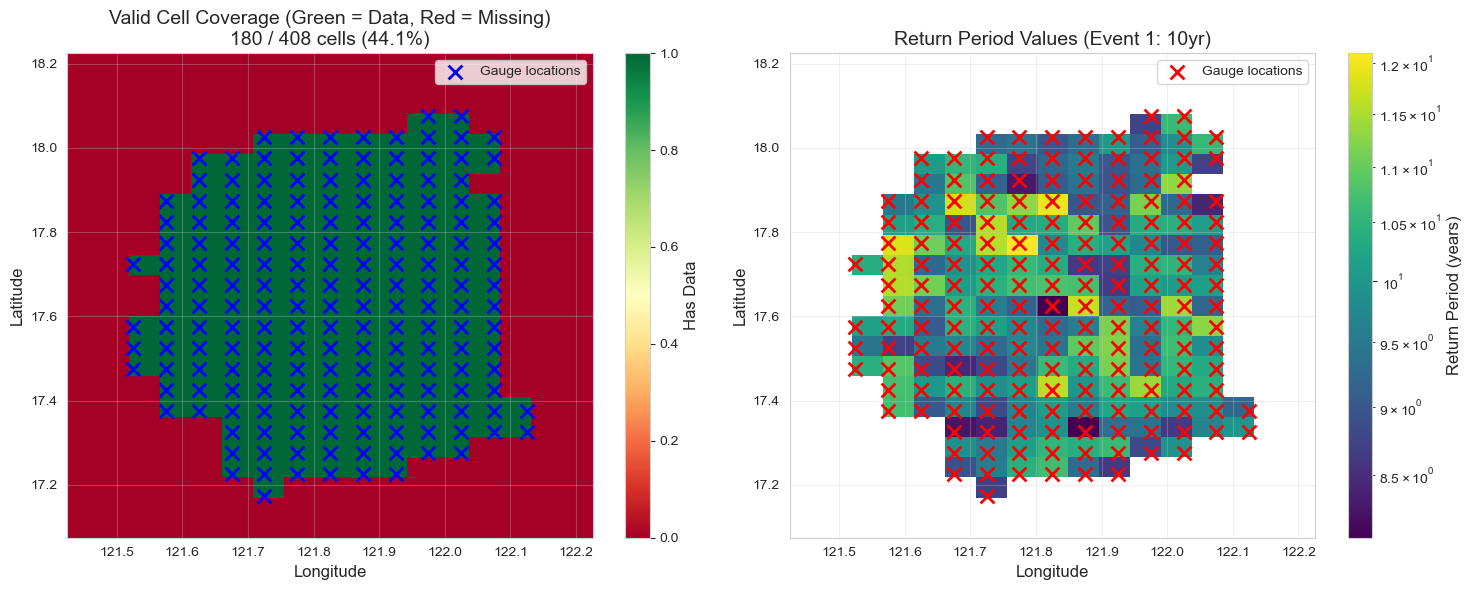


RETURN PERIOD GRID COVERAGE ANALYSIS
Event 1 (RP=    10yr): 180/408 cells ( 44.1%)
Event 2 (RP=    20yr): 180/408 cells ( 44.1%)
Event 3 (RP=    50yr): 180/408 cells ( 44.1%)
Event 4 (RP=    75yr): 180/408 cells ( 44.1%)
Event 5 (RP=   100yr): 180/408 cells ( 44.1%)
Event 6 (RP=   200yr): 180/408 cells ( 44.1%)
Event 7 (RP=   500yr): 180/408 cells ( 44.1%)

Overall statistics:
  Grid dimensions: 24 × 17 = 408 cells
  Average coverage: 44.1%
  Min coverage: 44.1%
  Max coverage: 44.1%

Gauge spatial distribution:
  Latitude range: 17.1750° to 18.0750°
  Longitude range: 121.5250° to 122.1250°
  Grid lat range: 17.0750° to 18.2250°
  Grid lon range: 121.4250° to 122.2250°
  Gap outside gauges: ~0.513° (due to 0.1° padding)

✓ Coverage map saved: return_period_coverage_map.png


In [31]:
# === Section 13.5B: Visualize Return Period Grid Coverage ===

"""
Visualize which grid cells have valid data vs. missing data.
Shows the spatial coverage of the return period conversion.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Create a binary mask of valid cells for the first event
valid_mask = ~np.isnan(return_period_grid[0])  # True where data exists

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Valid cell coverage
ax = axes[0]
im1 = ax.imshow(valid_mask, extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                 origin='lower', cmap='RdYlGn', aspect='auto', interpolation='nearest')
ax.scatter(gpd_params['longitude'].values, gpd_params['latitude'].values, 
          marker='x', s=100, c='blue', linewidths=2, label='Gauge locations', zorder=5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Valid Cell Coverage (Green = Data, Red = Missing)\n{np.sum(valid_mask)} / {valid_mask.size} cells ({100*np.sum(valid_mask)/valid_mask.size:.1f}%)')
ax.legend()
ax.grid(True, alpha=0.3)
cbar1 = plt.colorbar(im1, ax=ax)
cbar1.set_label('Has Data')

# Subplot 2: Return period values for first event
ax = axes[1]
rp_first = return_period_grid[0].copy()
im2 = ax.imshow(rp_first, extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                origin='lower', cmap='viridis', aspect='auto', norm='log')
ax.scatter(gpd_params['longitude'].values, gpd_params['latitude'].values,
          marker='x', s=100, c='red', linewidths=2, label='Gauge locations', zorder=5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Return Period Values (Event 1: {return_periods[0]:.0f}yr)')
ax.legend()
ax.grid(True, alpha=0.3)
cbar2 = plt.colorbar(im2, ax=ax)
cbar2.set_label('Return Period (years)')

plt.tight_layout()
plt.savefig(out_root / 'return_period_coverage_map.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n" + "="*70)
print("RETURN PERIOD GRID COVERAGE ANALYSIS")
print("="*70)

coverage_by_event = []
for event_idx in range(n_events):
    valid = ~np.isnan(return_period_grid[event_idx])
    pct = 100 * np.sum(valid) / valid.size
    coverage_by_event.append(pct)
    rp_target = return_periods[event_idx]
    print(f"Event {event_idx+1} (RP={rp_target:6.0f}yr): {np.sum(valid):3d}/{valid.size} cells ({pct:5.1f}%)")

print(f"\nOverall statistics:")
print(f"  Grid dimensions: {n_lat} × {n_lon} = {n_lat * n_lon} cells")
print(f"  Average coverage: {np.mean(coverage_by_event):.1f}%")
print(f"  Min coverage: {np.min(coverage_by_event):.1f}%")
print(f"  Max coverage: {np.max(coverage_by_event):.1f}%")

print(f"\nGauge spatial distribution:")
print(f"  Latitude range: {gpd_params['latitude'].min():.4f}° to {gpd_params['latitude'].max():.4f}°")
print(f"  Longitude range: {gpd_params['longitude'].min():.4f}° to {gpd_params['longitude'].max():.4f}°")
print(f"  Grid lat range: {lats.min():.4f}° to {lats.max():.4f}°")
print(f"  Grid lon range: {lons.min():.4f}° to {lons.max():.4f}°")
print(f"  Gap outside gauges: ~{0.025*(n_lat + n_lon)/2:.3f}° (due to 0.1° padding)")

print(f"\n✓ Coverage map saved: return_period_coverage_map.png")


## Section 13.5: Export Gridded Return Period for Petals Workflow

Convert discharge-based events into a spatial return period grid.
This grid is required by Notebook 02 for CLIMADA Petals flood depth interpolation.

**What this section does:**
1. Loads discharge intensity from Section 13 NetCDF
2. Maps each grid cell's discharge → return period using POT formula
3. Exports gridded return periods as `return-period.nc` for Notebook 02

**Key insight:** 
- Section 13 creates an event-based structure (discharge × return periods)
- This section transposes to a spatial perspective (return periods on a grid)
- Notebook 02 uses this grid to interpolate JRC flood depth maps


  Section 13B: Verifying CLIMADA NetCDF
• Loading: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\climada_flood_hazard.nc
• 
Dataset structure:
<xarray.Dataset> Size: 24kB
Dimensions:        (event: 7, latitude: 24, longitude: 17)
Coordinates:
  * latitude       (latitude) float64 192B 17.07 17.12 17.18 ... 18.18 18.23
  * longitude      (longitude) float64 136B 121.4 121.5 121.5 ... 122.2 122.2
  * event          (event) int32 28B 0 1 2 3 4 5 6
    return_period  (event) int32 28B ...
Data variables:
    intensity      (event, latitude, longitude) float32 11kB ...
    intensity_std  (event, latitude, longitude) float32 11kB ...
    event_id       (event) int32 28B ...
    event_name     (event) <U9 252B ...
    frequency      (event) float32 28B ...
Attributes: (12/19)
    title:                    CLIMADA-Compatible Flood Hazard (Formula-Based ...
    hazard_type:              RF
    conventions:              CF-1.8

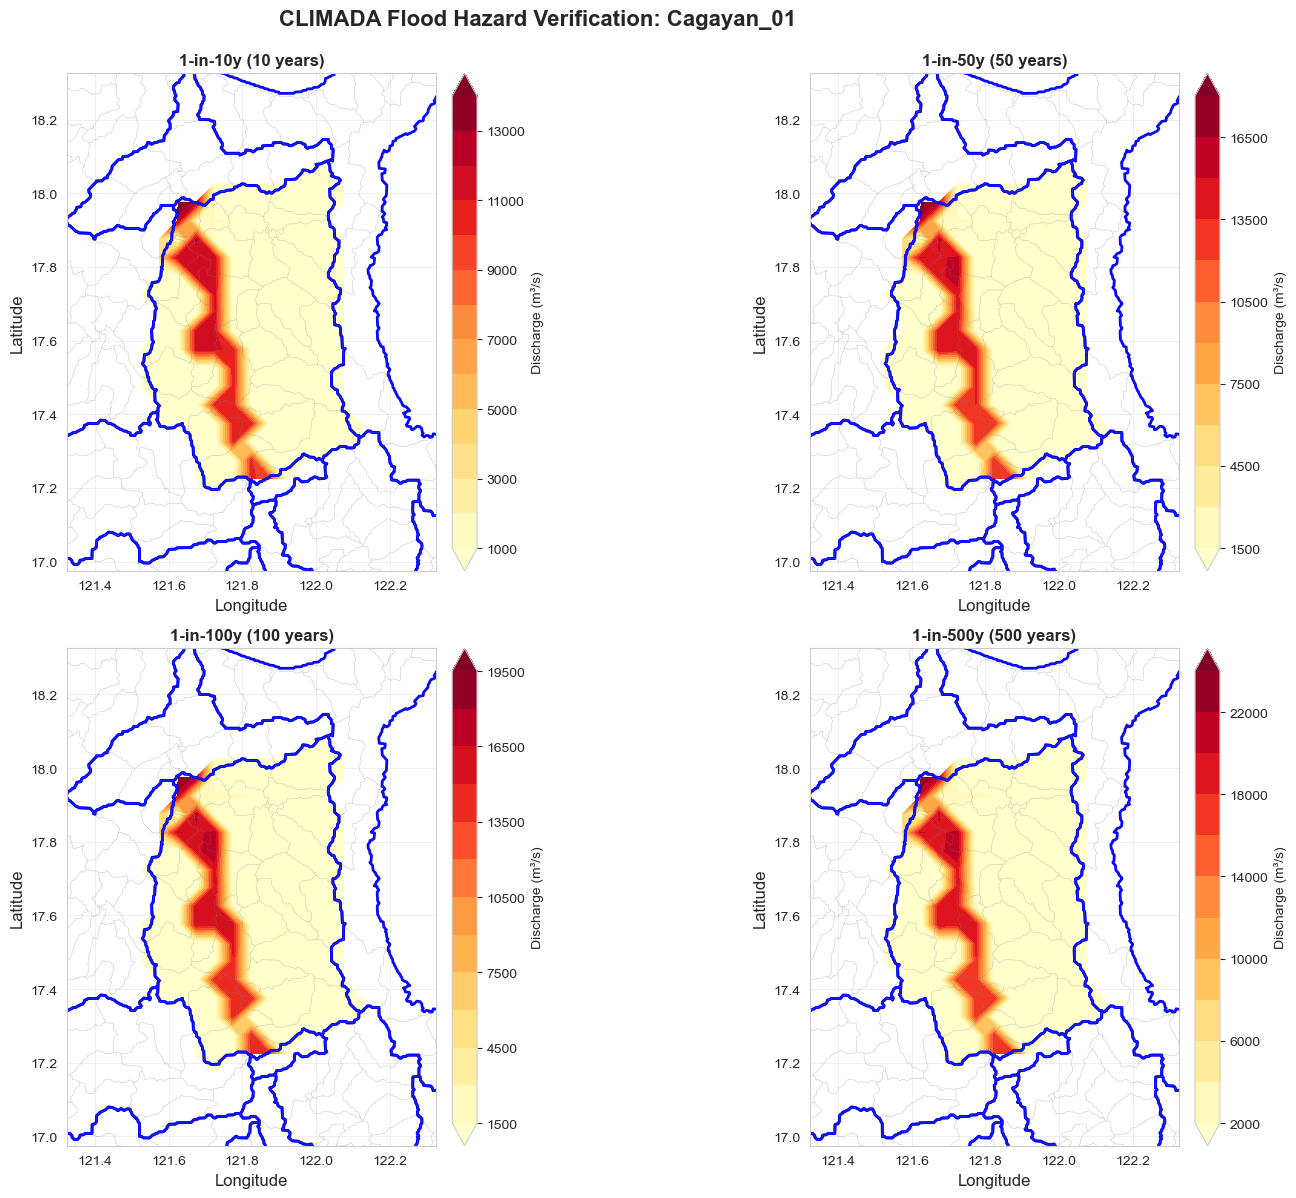

✓ ✓ CLIMADA NetCDF verification complete!


In [32]:
"""
## Section 13B: Verification of CLIMADA NetCDF (Gridded Flood Hazard)
Inspect the generated CLIMADA NetCDF to ensure all variables are present and formatted correctly.
This file contains gridded discharge intensity for different return period events.
"""

log.section("Section 13B: Verifying CLIMADA NetCDF")

# Use the correct CLIMADA NetCDF path from Section 13 (not return-period.nc)
climada_nc_path = out_root / "climada_flood_hazard.nc"
if not climada_nc_path.exists():
    raise FileNotFoundError(f"CLIMADA NetCDF not found: {climada_nc_path}")

log.step(f"Loading: {climada_nc_path}")
ds = xr.open_dataset(climada_nc_path)

# Display dataset structure
log.step("\nDataset structure:")
print(ds)

# Display metadata
log.step("\nGlobal attributes:")
for attr, value in ds.attrs.items():
    print(f"  {attr}: {value}")

# Verify dimensions
log.step("\nVerifying dimensions...")
n_events = ds.dims["event"]
n_lat = ds.dims["latitude"]
n_lon = ds.dims["longitude"]
print(f"  Events: {n_events}")
print(f"  Latitude: {n_lat}")
print(f"  Longitude: {n_lon}")

# Verify variables
log.step("\nVerifying variables...")
required_vars = ["intensity", "intensity_std", "event_id", "event_name", "frequency",
                 "return_period", "latitude", "longitude"]
for var in required_vars:
    if var in ds:
        print(f"  ✓ {var}")
        if var == "intensity":
            print(f"    Shape: {ds[var].shape}")
            print(f"    Valid data: {np.count_nonzero(~np.isnan(ds[var].values))} cells")
            print(f"    Range: [{np.nanmin(ds[var].values):.2f}, {np.nanmax(ds[var].values):.2f}] m³/s")
    else:
        print(f"  ✗ {var} (MISSING)")

# Verify return periods
log.step("\nVerifying return periods...")
return_periods = ds.return_period.values
event_names = ds.event_name.values
print(f"  Return periods: {return_periods}")
print(f"  Event names: {list(event_names)}")

# Check frequency (should equal 1/return_period difference for exceedance)
log.step("\nVerifying frequency values...")
for i, rp in enumerate(return_periods):
    actual_freq = float(ds.frequency.isel(event=i).values)
    print(f"  Event {i}: RP={int(rp)}yr, freq={actual_freq:.6f}")

# Statistical summary
log.step("\nStatistical summary of intensity field...")
intensity_all = ds.intensity.values
print(f"  Total cells: {intensity_all.size}")
print(f"  Valid cells: {np.count_nonzero(~np.isnan(intensity_all))}")
print(f"  Invalid/NaN: {np.count_nonzero(np.isnan(intensity_all))}")
print(f"  Min: {np.nanmin(intensity_all):.4f} m³/s")
print(f"  Max: {np.nanmax(intensity_all):.4f} m³/s")
print(f"  Mean: {np.nanmean(intensity_all):.4f} m³/s")
print(f"  Median: {np.nanmedian(intensity_all):.4f} m³/s")

# Check coefficient of variation across return periods
log.step("\nAnalyzing spatial variation across return periods...")
cv = ds.intensity.std(dim='event') / ds.intensity.mean(dim='event')
cv_mean = float(np.nanmean(cv.values))
cv_median = float(np.nanmedian(cv.values))
cv_range = (float(np.nanmin(cv.values)), float(np.nanmax(cv.values)))
print(f"  CV mean: {cv_mean:.3f}")
print(f"  CV median: {cv_median:.3f}")
print(f"  CV range: [{cv_range[0]:.3f}, {cv_range[1]:.3f}]")

# Create verification map showing intensity at selected return periods
log.step("\nCreating verification map...")

# Select 4 return periods to plot
plot_events = [0, n_events // 3, 2 * n_events // 3, n_events - 1] if n_events >= 4 else list(range(n_events))

# Calculate extent for zooming to AOI
lon_min, lon_max = ds.longitude.min().item(), ds.longitude.max().item()
lat_min, lat_max = ds.latitude.min().item(), ds.latitude.max().item()
padding = 0.1  # Add small padding around data extent

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, event_idx in enumerate(plot_events[:4]):  # Max 4 plots
    ax = axes[i]
    
    # Get intensity for this event
    event_name = str(ds.event_name.isel(event=event_idx).values)
    return_period = int(ds.return_period.isel(event=event_idx).values)
    intensity = ds.intensity.isel(event=event_idx)
    
    # Create contour plot
    im = ax.contourf(
        ds.longitude, 
        ds.latitude,
        intensity,
        levels=15,
        cmap="YlOrRd",
        extend="both"
    )
    
    # Overlay basin boundary if available (zoom to AOI only)
    if not USE_MUNI_AOI and context_gdf is not None:
        try:
            context_gdf.boundary.plot(ax=ax, color="blue", linewidth=2.0, label="Context basin")
        except:
            pass
    
    # Add L12 basins in background (only the filtered ones from Section 3)
    try:
        # l12_gdf should already be filtered from Section 3
        l12_gdf.boundary.plot(ax=ax, color="gray", linewidth=0.3, alpha=0.3)
    except:
        pass
    
    # Set axis limits to zoom into the AOI
    ax.set_xlim(lon_min - padding, lon_max + padding)
    ax.set_ylim(lat_min - padding, lat_max + padding)
    
    ax.set_title(f"{event_name} ({return_period} years)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02)
    cbar.set_label("Discharge (m³/s)", fontsize=10)

# Mode-agnostic title
basin_name = basin_cfg.basin_id if basin_cfg else "MUNI_SELECTION"
plt.suptitle(
    f"CLIMADA Flood Hazard Verification: {basin_name}",
    fontsize=16,
    fontweight="bold",
    y=0.995
)
plt.tight_layout()

# Save
verification_map_path = out_root / "climada_verification_map.png"
plt.savefig(verification_map_path, dpi=150, bbox_inches="tight")
log.step(f"✓ Saved: {verification_map_path}")
plt.show()

# Close dataset
ds.close()

log.success("✓ CLIMADA NetCDF verification complete!")


## 12. Create Maps & Visualizations for Stakeholders

**What this step does:**
Generates professional maps and charts showing:
- How flood intensity varies across your analysis area (basin)
- Return period values displayed on spatial maps
- Clear visualizations for reporting to decision-makers

**Why it matters:**
Maps make flood risk understandable and actionable for:
- **Government officials** - see which areas are most at risk
- **Emergency planners** - identify priority zones for preparation
- **Communities** - understand local flood risk in accessible format

**Output:** Static images (PNG) and interactive maps ready for presentations or reports

In [33]:
"""
Section 13C: Stakeholder Spatial Return Level Maps

Creates professional spatial visualizations of flood hazard intensity:
1. Multi-panel return period intensity maps (2yr, 10yr, 100yr, 500yr)
2. Coefficient of variation (uncertainty) spatial map
3. Basin context layers (boundaries, rivers, administrative areas)
4. Publication-ready cartography with proper legends and scale bars
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import seaborn as sns
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from pathlib import Path

log.section("SECTION 13C: Stakeholder Spatial Return Level Maps")

# Define output directories
fig_dir = out_root / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Load CLIMADA NetCDF
netcdf_path = out_root / "climada_flood_hazard.nc"

if not netcdf_path.exists():
    log.error(f"CLIMADA NetCDF not found: {netcdf_path}")
    log.warn("Please run Section 13 first")
else:
    log.step("Loading CLIMADA NetCDF...")
    ds = xr.open_dataset(netcdf_path)
    
    # Mode-agnostic basin name
    basin_name = basin_cfg.basin_id if basin_cfg else "MUNI_SELECTION"
    
    # Set professional cartographic styling
    sns.set_style("white")
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
    
    # --- Figure 1: Multi-Panel Return Period Maps ---
    log.step("Creating multi-panel return period maps...")
    
    fig1, axes = plt.subplots(2, 2, figsize=(16, 14), subplot_kw={'projection': None})
    axes = axes.flatten()
    
    # Select key return periods: 2yr, 10yr, 100yr, 500yr
    plot_events = []
    plot_rps = [2, 10, 100, 500]
    for target_rp in plot_rps:
        # Find event index closest to target return period
        rp_values = ds.return_period.values
        event_idx = np.argmin(np.abs(rp_values - target_rp))
        plot_events.append(event_idx)
    
    # Use Viridis colormap (colorblind-friendly)
    cmap = plt.cm.viridis
    
    # Load basin boundary for context
    try:
        if basin_cfg and hasattr(basin_cfg, 'aoi_geojson'):
            basin_gdf = gpd.read_file(basin_cfg.aoi_geojson)
        else:
            basin_gdf = None
    except Exception as e:
        log.warn(f"Could not load basin boundary: {e}")
        basin_gdf = None
    
    for ax_idx, event_idx in enumerate(plot_events):
        ax = axes[ax_idx]
        
        # Get data for this event
        event_name = str(ds.event_name.isel(event=event_idx).values)
        return_period = int(ds.return_period.isel(event=event_idx).values)
        intensity = ds.intensity.isel(event=event_idx)
        
        # Define intensity bins for consistent color scale
        vmin, vmax = 0, np.nanpercentile(ds.intensity.values, 95)
        
        # Plot intensity
        im = ax.contourf(
            ds.longitude,
            ds.latitude,
            intensity,
            levels=20,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            extend='max'
        )
        
        # Overlay basin boundary
        if basin_gdf is not None:
            basin_gdf.boundary.plot(ax=ax, color='black', linewidth=2, zorder=5, label='Basin boundary')
        
        # Styling
        ax.set_title(f'{return_period}-Year Return Period', fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('Longitude (°E)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Latitude (°N)', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=9)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.9)
        cbar.set_label('Discharge (m³/s)', fontsize=10, fontweight='bold')
        cbar.ax.tick_params(labelsize=9)
    
    # Overall title - mode-agnostic
    fig1.suptitle(
        f'Flood Hazard Intensity Maps: {basin_name}\nPOT/GPD Return Level Analysis',
        fontsize=18,
        fontweight='bold',
        y=0.98
    )
    
    # Metadata footer
    footer_text = (
        f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}  |  "
        f"Method: Peaks-over-Threshold with GPD  |  "
        f"Grid Resolution: {ds.attrs.get('grid_resolution_degrees', 0.05)}°  |  "
        f"Bootstrap Samples: 20"
    )
    fig1.text(0.5, 0.01, footer_text, ha='center', fontsize=10, 
              style='italic', color='gray')
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    
    # Save figure 1
    map1_path = fig_dir / "stakeholder_spatial_return_periods.png"
    fig1.savefig(map1_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig1)
    
    log.success(f"✓ Return period maps saved: {map1_path.name}")
    
    # --- Figure 2: Uncertainty Map (Coefficient of Variation) ---
    log.step("Creating coefficient of variation uncertainty map...")
    
    fig2, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': None})
    
    # Compute CV across all events (mean CV at each location)
    cv = ds.intensity_std / ds.intensity
    cv_mean = cv.mean(dim='event')
    
    # Use RdYlBu_r colormap (red=high uncertainty, blue=low uncertainty)
    cmap_cv = plt.cm.RdYlBu_r
    
    # Plot CV
    cv_vmax = 0.5  # Cap at 50% CV for color scale
    im_cv = ax.contourf(
        ds.longitude,
        ds.latitude,
        cv_mean,
        levels=20,
        cmap=cmap_cv,
        vmin=0,
        vmax=cv_vmax,
        extend='max'
    )
    
    # Overlay basin boundary
    if basin_gdf is not None:
        basin_gdf.boundary.plot(ax=ax, color='black', linewidth=2.5, zorder=5)
    
    # Styling - mode-agnostic
    ax.set_title(
        f'Uncertainty Map: Mean Coefficient of Variation\n{basin_name}',
        fontsize=16,
        fontweight='bold',
        pad=15
    )
    ax.set_xlabel('Longitude (°E)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude (°N)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=10)
    
    # Colorbar
    cbar_cv = plt.colorbar(im_cv, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    cbar_cv.set_label('Coefficient of Variation (CV)', fontsize=12, fontweight='bold')
    cbar_cv.ax.tick_params(labelsize=10)
    
    # Add interpretation guide
    interpretation_text = (
        "Interpretation:\n"
        "• Low CV (blue): High confidence in estimates\n"
        "• Medium CV (yellow): Moderate uncertainty\n"
        "• High CV (red): High uncertainty, use with caution"
    )
    ax.text(
        0.02, 0.98, interpretation_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    )
    
    # Statistics box
    cv_stats_text = (
        f"Basin Statistics:\n"
        f"Mean CV: {float(cv_mean.mean()):.3f}\n"
        f"Median CV: {float(cv_mean.median()):.3f}\n"
        f"Max CV: {float(cv_mean.max()):.3f}"
    )
    ax.text(
        0.98, 0.98, cv_stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='orange')
    )
    
    # Metadata footer
    footer_cv = (
        f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}  |  "
        f"CV = Bootstrap Std Dev / Mean  |  "
        f"Lower CV indicates higher confidence in estimates"
    )
    fig2.text(0.5, 0.01, footer_cv, ha='center', fontsize=10, 
              style='italic', color='gray')
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.98])
    
    # Save figure 2
    map2_path = fig_dir / "stakeholder_uncertainty_map.png"
    fig2.savefig(map2_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig2)
    
    log.success(f"✓ Uncertainty map saved: {map2_path.name}")
    
    # Close dataset
    ds.close()
    
    # Summary report
    log.table("Section 13C Summary", {
        "Return period maps": map1_path.name,
        "Uncertainty map": map2_path.name,
        "Panels (Fig 1)": "4 (2yr, 10yr, 100yr, 500yr)",
        "Resolution": f"{ds.attrs.get('grid_resolution_degrees', 0.05)}°",
        "Colormap (intensity)": "Viridis (colorblind-friendly)",
        "Colormap (uncertainty)": "RdYlBu_r (red=high uncertainty)",
        "Format": "PNG @ 300 DPI (publication-ready)",
    })

log.success("Section 13C complete ✓")



  SECTION 13C: Stakeholder Spatial Return Level Maps
• Loading CLIMADA NetCDF...
• Creating multi-panel return period maps...
✓ ✓ Return period maps saved: stakeholder_spatial_return_periods.png
• Creating coefficient of variation uncertainty map...
✓ ✓ Uncertainty map saved: stakeholder_uncertainty_map.png

Section 13C Summary:
  Return period maps...................... stakeholder_spatial_return_periods.png
  Uncertainty map......................... stakeholder_uncertainty_map.png
  Panels (Fig 1).......................... 4 (2yr, 10yr, 100yr, 500yr)
  Resolution.............................. 0.05°
  Colormap (intensity).................... Viridis (colorblind-friendly)
  Colormap (uncertainty).................. RdYlBu_r (red=high uncertainty)
  Format.................................. PNG @ 300 DPI (publication-ready)
✓ Section 13C complete ✓


In [34]:
import json

# Export run configuration metadata for notebook 02 auto-detection
# Extract basin_id from output directory structure: out_root = .../evt_pot/{BASIN_ID}/{RUN_TAG}
basin_id = out_root.parent.name

metadata = {
    "selection_mode": "municipality" if USE_MUNI_AOI else "basin",
    "use_muni_aoi": USE_MUNI_AOI,
    "basin_id": basin_id,
    "run_tag": run_tag,
    "timestamp": pd.Timestamp.now().isoformat(),
}

# Add selected municipalities if in municipality mode
if USE_MUNI_AOI and 'selected_munis' in locals():
    # Count the number of selected municipalities
    metadata["selected_municipalities"] = len(adm3_ids)
    
    # Add the list of adm3_ids
    metadata["adm3_ids"] = adm3_ids
    
    # Add municipality names from the geojson
    # Find the name field in adm3_gdf (could be ADM3_EN, adm3_name, etc.)
    name_field = None
    for potential_field in ['ADM3_EN', 'adm3_name', 'NAME_3', 'name', 'ADM3_NAME']:
        if potential_field in adm3_gdf.columns:
            name_field = potential_field
            break
    
    if name_field:
        # Get the names for the selected adm3_ids
        selected_rows = adm3_gdf[adm3_gdf[adm3_id_field].isin(adm3_ids)]
        adm3_names = selected_rows[name_field].tolist()
        metadata["adm3_names"] = adm3_names
    else:
        log.warn(f"Could not find name field in ADM3 GeoDataFrame. Available columns: {list(adm3_gdf.columns)}")
        metadata["adm3_names"] = []

# Write metadata file to output directory
config_file = out_root / "run_config.json"
config_file.write_text(json.dumps(metadata, indent=2))

log.success(f"Run configuration metadata saved: {config_file}")
log.table("Run Configuration Metadata", metadata)

✓ Run configuration metadata saved: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\run_config.json

Run Configuration Metadata:
  selection_mode.......................... basin
  use_muni_aoi............................ False
  basin_id................................ Cagayan_01
  run_tag................................. 2026-01-19_calib-test
  timestamp............................... 2026-02-20T18:59:16.181811
